In [1]:
import pandas as pd
import numpy as np

## Extract table

In [2]:
data1 = pd.read_excel("extract2.xlsx")
data1.drop(index=0, inplace=True)
data1.drop(columns=['PLY_NO', 'PYG_GST', 'APR_FLG', 'BSN_USE', 'BLD_CLM_CNT'], inplace=True)   # dropping cols with same values throughout
data1.reset_index(drop=True, inplace=True)
data1

,PLY_PRD,CST_OCP,TIR_PRM_AM,UCP_DY,UCP_RSN,OWS_DTL,SUM_INU,PRM_AM,PRM_WTH_IPT,RSK_PRM_INC_CRD_SCR,...,TIR_RSK_PRM,ITM_LMT_VL,MAN_PRT_PRM,ACD_PRM,OBL_PRM,PRV_ISN_BLD,PRV_ISN_CNE,PPT_ELG,RSK_PRM_OVR_TAX_SCG,CTS_CLM_CNT
0,DC1,RETI,0,30,Pendingsale(deceased),OR,NaN,NaN,NaN,NaN,...,0,550000,NaN,NaN,NaN,9,9,1,15.68,NaN
1,DC1,OTHR,195.2,30,NaN,OR,500000,174.29,195.2,162.41,...,159.51,99999999,NaN,NaN,NaN,5,5,1,34.8,0
2,DC1,OTHR,NaN,30,NaN,OR,0,39.6,NaN,NaN,...,NaN,99999999,1.789269,0.515735,0,7,7,1,77.99,0
3,DC1,OTHR,0,30,Pendingsale(deceased),UR,0,0,0,0,...,0,100000,NaN,NaN,NaN,0,2,1,27.13,0
4,DC1,RETI,0,30,NaN,OR,0,0,0,NaN,...,0,75000,0.688533,0.111698,0.068097,99,9,1,24.39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,DC1,RETI,0,30,NaN,OR,0,0,0,NaN,...,0,1000000,4.24824,0.3502,0.33187,99,4,1,31.32,0
72,DC1,OTHR,0,30,Pendingsale(deceased),FR,NaN,NaN,NaN,NaN,...,38.92,100000000,NaN,NaN,NaN,0,0,1,57.67,0
73,DC1,RETI,0,30,NaN,OR,NaN,NaN,NaN,NaN,...,0,100000,NaN,NaN,NaN,99,99,NaN,41.34,0
74,DC1,RETI,27.59,30,NaN,OR,2000,24.63,27.59,NaN,...,11.7,5000,9.31995,0.39542,0,99,0,NaN,27.06,0


In [3]:
print("Column, Missing Values, Unique Values")
for col in data1.columns:
    print(f"{col}, {data1[col].isna().sum()}, {data1[col].nunique()}")

Column, Missing Values, Unique Values
PLY_PRD, 0, 2
CST_OCP, 20, 3
TIR_PRM_AM, 8, 24
UCP_DY, 18, 2
UCP_RSN, 42, 1
OWS_DTL, 18, 4
SUM_INU, 37, 10
PRM_AM, 37, 17
PRM_WTH_IPT, 40, 15
RSK_PRM_INC_CRD_SCR, 64, 8
RSK_PRM_NO_CRD_SCR, 64, 8
CVR_IND, 10, 2
CVR_TYP_LMT, 60, 6
CVR_SEL, 45, 2
TIR_LMT_VL, 25, 11
TIR_RSK_PRM, 3, 30
ITM_LMT_VL, 3, 20
MAN_PRT_PRM, 42, 31
ACD_PRM, 42, 26
OBL_PRM, 42, 22
PRV_ISN_BLD, 6, 11
PRV_ISN_CNE, 6, 11
PPT_ELG, 25, 1
RSK_PRM_OVR_TAX_SCG, 0, 76
CTS_CLM_CNT, 35, 2


In [4]:
categorical_cols = ["CST_OCP", "UCP_DY", "OWS_DTL", "CVR_IND", "CVR_SEL", "CTS_CLM_CNT"]

# Replace string indicators of missingness with NaN
data1.replace(["", "NA", "None"], np.nan, inplace=True)

for col in categorical_cols:
    if col in data1.columns:
        choices = data1[col].dropna().unique()
        data1[col] = data1[col].apply(lambda x: np.random.choice(choices) if pd.isna(x) else x)

# standard_fill_cols
data1["UCP_RSN"] = data1["UCP_RSN"].fillna("Unknown")
data1["PPT_ELG"] = data1["PPT_ELG"].fillna(0)

C:\Users\niksh\AppData\Local\Temp\ipykernel_17260\3220750870.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data1.replace(["", "NA", "None"], np.nan, inplace=True)


In [5]:
categorical_cols.append("UCP_RSN")
categorical_cols.append("PPT_ELG")
categorical_cols.append("PLY_PRD")

rem_cols = data1.columns.difference(categorical_cols).tolist()

from scipy.stats import norm

for col in rem_cols:
    if col in data1.columns:
        non_null_values = data1[col].dropna().values
        if len(non_null_values) == 0:
            continue

        # Fit a normal distribution
        mu, sigma = norm.fit(non_null_values)

        n_missing = data1[col].isna().sum()
        # Generate samples
        sampled_values = np.random.normal(mu, sigma, n_missing)

        # Ensure no negatives — resample those that are < 0
        while np.any(sampled_values < 0):
            neg_idx = sampled_values < 0
            sampled_values[neg_idx] = np.random.normal(mu, sigma, np.sum(neg_idx))

        data1.loc[data1[col].isna(), col] = sampled_values

In [ ]:
data1.to_csv("extract2_cleaned.csv", index=False)

## Fraud Table

In [32]:
data2 = pd.read_excel("fraud.xlsx")
data2 = data2.dropna(subset=['CLAIM_TYPE_DESCRIPTION']).reset_index(drop=True)
data2

,REGISTERED_DATE,LOSS_DATE,CLAIM_TYPE_DESCRIPTION,INVEST_DATE,Closed Date,SAVED_VALUE_ESTIMATE,ACTION_STATUS_DESCRIPTION,PRODUCT_CODE,REASON,Rule Outcome Code,ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME
0,2023-04-17,2023-04-17,Escape of Water,2023-04-20,2023-05-12,3000.0,Suspect,HAS,Fraud Suspected - Exaggerated,S003,2023-04-19 12:00:10.447
1,2023-04-17,2023-04-16,Theft,2023-04-17,2023-04-17,0.0,Clear after Investigation,HAA,Null,S003,2023-04-17 15:33:45.303
2,2023-04-17,2023-02-18,Theft,2023-04-20,2023-04-25,45190.0,Clear after Investigation,DC1,Null,S002,2023-04-20 09:31:44.437
3,2023-04-17,2023-04-17,Accidental damage Option,2023-04-18,2023-05-25,343.0,Suspect,DC1,Fraud Suspected - Claim Paid,S001,2023-04-17 16:15:32.263
4,2023-04-17,2023-04-15,Accidental damage Option,2023-04-25,2023-10-03,3000.0,Suspect,DC1,Fraud Suspected - Exaggerated,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...
9355,2025-07-28,2025-07-20,Escape of Water,2025-08-02,2025-08-05,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 13:14:30.467
9356,2025-07-28,2025-07-28,Fire,2025-07-31,2025-07-31,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 15:59:23.347
9357,2025-08-01,2025-08-01,Fire,2025-08-07,2025-08-07,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:22:51.573
9358,2025-08-01,2025-07-31,Accidental loss (EXC),2025-08-08,2025-08-13,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:50:01.883


In [33]:
print("Column, Missing Values, Unique Values")
for col in data2.columns:
    print(f"{col}, {data2[col].isna().sum()}, {data2[col].nunique()}")

Column, Missing Values, Unique Values
REGISTERED_DATE, 0, 798
LOSS_DATE, 0, 925
CLAIM_TYPE_DESCRIPTION, 0, 19
INVEST_DATE, 0, 675
Closed Date, 0, 655
SAVED_VALUE_ESTIMATE, 0, 1193
ACTION_STATUS_DESCRIPTION, 0, 3
PRODUCT_CODE, 0, 8
REASON, 0, 24
Rule Outcome Code, 89, 3
ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME, 89, 9271


In [34]:
col = "Rule Outcome Code"
choices = data2[col].dropna().unique()
data2[col] = data2[col].apply(lambda x: np.random.choice(choices) if pd.isna(x) else x)

# Fill NA in ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME with a random date between REGISTERED_DATE and REGISTERED_DATE + 4 days, using normal distribution
mask = data2['ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME'].isna()
register_dates = data2.loc[mask, 'REGISTERED_DATE']

# Generate random offsets (in days) from a normal distribution centered at 2, std=1, clipped to [0, 4]
offsets = np.clip(np.random.normal(loc=2, scale=1, size=mask.sum()), 0, 4)
random_dates = register_dates + pd.to_timedelta(offsets, unit='D')

data2.loc[mask, 'ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME'] = random_dates
data2

,REGISTERED_DATE,LOSS_DATE,CLAIM_TYPE_DESCRIPTION,INVEST_DATE,Closed Date,SAVED_VALUE_ESTIMATE,ACTION_STATUS_DESCRIPTION,PRODUCT_CODE,REASON,Rule Outcome Code,ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME
0,2023-04-17,2023-04-17,Escape of Water,2023-04-20,2023-05-12,3000.0,Suspect,HAS,Fraud Suspected - Exaggerated,S003,2023-04-19 12:00:10.447000000
1,2023-04-17,2023-04-16,Theft,2023-04-17,2023-04-17,0.0,Clear after Investigation,HAA,Null,S003,2023-04-17 15:33:45.303000000
2,2023-04-17,2023-02-18,Theft,2023-04-20,2023-04-25,45190.0,Clear after Investigation,DC1,Null,S002,2023-04-20 09:31:44.437000000
3,2023-04-17,2023-04-17,Accidental damage Option,2023-04-18,2023-05-25,343.0,Suspect,DC1,Fraud Suspected - Claim Paid,S001,2023-04-17 16:15:32.263000000
4,2023-04-17,2023-04-15,Accidental damage Option,2023-04-25,2023-10-03,3000.0,Suspect,DC1,Fraud Suspected - Exaggerated,S003,2023-04-19 14:36:43.570258989
...,...,...,...,...,...,...,...,...,...,...,...
9355,2025-07-28,2025-07-20,Escape of Water,2025-08-02,2025-08-05,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 13:14:30.467000000
9356,2025-07-28,2025-07-28,Fire,2025-07-31,2025-07-31,0.0,Clear after Investigation,DC2,Null,S001,2025-07-28 15:59:23.347000000
9357,2025-08-01,2025-08-01,Fire,2025-08-07,2025-08-07,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:22:51.573000000
9358,2025-08-01,2025-07-31,Accidental loss (EXC),2025-08-08,2025-08-13,0.0,Clear after Investigation,DC2,Null,S002,2025-08-01 12:50:01.883000000


In [ ]:
data2.to_csv("fraud_cleaned.csv", index=False)

## Scaling

In [ ]:
from scipy.stats import gaussian_kde

def scale_dataframe(data, target_rows, categorical_cols, numeric_cols, random_state=None):
    """
    Scale up a mixed-type DataFrame to target_rows by synthetic resampling 
    while preserving per-column data distributions.
    """
    np.random.seed(random_state)
    new_data = pd.DataFrame()

    # --- Handle categorical columns ---
    for col in categorical_cols:
        if col not in data.columns:
            continue
        col_data = data[col]
        # Compute probability of each category
        probs = col_data.value_counts(normalize=True)
        # Sample categories according to observed frequency
        sampled = np.random.choice(probs.index, size=target_rows, p=probs.values)
        new_data[col] = sampled

    # --- Handle numeric columns ---
    for col in numeric_cols:
        if col not in data.columns:
            continue
        col_data = data[col].values
        # Fit Kernel Density Estimation (KDE)
        kde = gaussian_kde(col_data)
        # Generate synthetic samples
        sampled = kde.resample(target_rows).reshape(-1)
        # Clip to observed range (optional, ensures realism)
        sampled = np.clip(sampled, col_data.min(), col_data.max())
        new_data[col] = sampled

    # Preserve column order as in the original DataFrame
    new_data = new_data[data.columns]

    return new_data.reset_index(drop=True)

# Generate scaled data
scaled_data1 = scale_dataframe(data1, target_rows=15000,
                              categorical_cols=categorical_cols,
                              numeric_cols=rem_cols,
                              random_state=42)

scaled_data1.to_csv("scaled_extract2.csv", index=False)

In [ ]:
def scale_dataframe2(
    data,
    target_rows,
    date_cols,
    categorical_cols,
    numeric_cols,
    random_state=None
):
    """
    Rule-based synthetic scaling of a mixed-type dataframe with:
    - Date columns (sampled within range)
    - Categorical columns (sampled by frequency)
    - Numeric columns (KDE resampling)
    """

    if random_state is not None:
        np.random.seed(random_state)

    new_data = pd.DataFrame()

    # --- 1. DATE COLUMNS -----------------------------------------------------
    for col in date_cols:
        if col not in data.columns:
            continue
        
        # Convert to datetime (if not already)
        col_data = pd.to_datetime(data[col])

        # Range of observed dates
        min_date = col_data.min()
        max_date = col_data.max()

        # Sample random dates within observed range
        total_days = (max_date - min_date).days
        rand_days = np.random.randint(0, total_days + 1, size=target_rows)
        sampled_dates = min_date + pd.to_timedelta(rand_days, unit="D")

        new_data[col] = sampled_dates.astype(str)

    # --- 2. CATEGORICAL COLUMNS --------------------------------------------
    for col in categorical_cols:
        if col not in data.columns:
            continue

        col_data = data[col]
        probs = col_data.value_counts(normalize=True)

        sampled = np.random.choice(
            probs.index,
            size=target_rows,
            p=probs.values
        )
        new_data[col] = sampled

    # --- 3. NUMERIC COLUMNS --------------------------------------------------
    for col in numeric_cols:
        if col not in data.columns:
            continue
        
        col_data = data[col].astype(float).values

        # KDE Fit
        kde = gaussian_kde(col_data)

        sampled_vals = kde.resample(target_rows).reshape(-1)

        # Clip to keep realism
        sampled_vals = np.clip(sampled_vals, col_data.min(), col_data.max())

        new_data[col] = sampled_vals

    # Match column ordering with original dataframe
    new_data = new_data[data.columns]

    return new_data.reset_index(drop=True)

date_cols = [
    "REGISTERED_DATE",
    "LOSS_DATE",
    "INVEST_DATE",
    "Closed Date",
    "ENQUIRY_REALTIME_RESULT_CREATE_DATE_TIME"
]

categorical_cols = [
    "CLAIM_TYPE_DESCRIPTION",
    "ACTION_STATUS_DESCRIPTION",
    "PRODUCT_CODE",
    "REASON",
    "Rule Outcome Code"
]

numeric_cols = ["SAVED_VALUE_ESTIMATE"]

scaled_data2 = scale_dataframe2(
    data=data2,
    target_rows=15000,
    date_cols=date_cols,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    random_state=42
)

scaled_data2.to_csv("fraud_scaled.csv", index=False)

In [ ]:
scaled_data1 = scaled_data1.reset_index(drop=True)
scaled_data2 = scaled_data2.reset_index(drop=True)

data3 = pd.concat([scaled_data1, scaled_data2], axis=1)
data3

In [ ]:
data3.to_csv("combined_scaled.csv", index=False)

## Feature expansion

In [3]:
import numpy as np
import pandas as pd
import random
from scipy.special import expit

In [ ]:
data = pd.read_csv("data_template.csv")
data


,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,plumbing_elec_age,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims,premium_payment_behaviour,property_market_value,short_term_letting
0,Random no,Random 6 categorical values,"Categorical - (housewife, retired, other)","categorical - 1, 2, 3",Tier based values,"how many occupants in house, including owners ...",no of PGs,Y/N,"30, 60, 90",unoccupied reason,...,age of plumbing and electrical equipmements,0 or 1,0 or 1,0 or 1,1 to 5,urban/rural,no of claims in last 5 years,metric of the history of the customer's paymen...,"market value of the property, in logical accor...",is the property open for short term letting li...


In [ ]:
def generate_uk_home_insurance_data(n_records=1000):
    """
    Generate realistic UK home insurance data based on demographics and market research.
    Returns: List of dictionaries with insurance policy data
    """
    
    data = []
    
    # Product categories based on UK market
    products = ['Buildings', 'Contents', 'Combined', 'Landlord', 'Premium Combined', 'Standard']
    
    # Occupation distribution (UK weighted)
    occupations = {
        'retired': 0.28,
        'housewife': 0.08,
        'professional': 0.22,
        'white_collar': 0.30,
        'skilled_worker': 0.08,
        'other': 0.04
    }
    
    # Property type distribution (UK 2024)
    property_types = {
        'Terraced': 0.26,
        'Semi': 0.24,
        'Flat': 0.24,
        'Detached': 0.19,
        'Bungalow': 0.07
    }
    
    # Urban/rural split (UK ~83% urban)
    urban_rural_dist = {'urban': 0.83, 'rural': 0.17}
    
    for i in range(n_records):
        # Basic policy info
        policy_no = 100000 + i
        policy_product = random.choice(products)
        
        # Occupation
        cust_occupation = random.choices(
            list(occupations.keys()),
            weights=list(occupations.values())
        )[0]
        
        # Tier (1=basic, 2=standard, 3=premium)
        tier = random.choices([1, 2, 3], weights=[0.35, 0.50, 0.15])[0]
        
        # Tier-based premium amounts
        tier_premium_base = {1: 180, 2: 320, 3: 580}
        tier_premium_amt = tier_premium_base[tier] * random.uniform(0.85, 1.15)
        
        # Property type
        property_type = random.choices(
            list(property_types.keys()),
            weights=list(property_types.values())
        )[0]
        
        # Occupants (1-6, weighted toward 2-4)
        occupants_count = random.choices([1, 2, 3, 4, 5, 6], weights=[0.15, 0.30, 0.25, 0.20, 0.07, 0.03])[0]
        
        # Paying guests (0-2, mostly 0)
        paying_guest_no = random.choices([0, 1, 2], weights=[0.92, 0.06, 0.02])[0]
        
        # Business use (5% have it)
        business_use = 'Y' if random.random() < 0.05 else 'N'
        
        # Unoccupied days (90% have 0, rest have 30/60/90)
        unoccupied_days = random.choices([0, 30, 60, 90], weights=[0.90, 0.05, 0.03, 0.02])[0]
        unoccupied_reason = random.choice(['', 'holiday_home', 'renovation', 'relocation']) if unoccupied_days > 0 else ''
        
        # Owner details
        owner_details = random.choices(
            ['owner', 'user', 'legal_lease', 'financier'],
            weights=[0.75, 0.15, 0.08, 0.02]
        )[0]
        
        # Sum insured (rebuild cost, varies by property type)
        base_sum_insured = {
            'Flat': 200000,
            'Terraced': 300000,
            'Semi': 350000,
            'Bungalow': 320000,
            'Detached': 500000
        }
        sum_insured = int(base_sum_insured[property_type] * random.uniform(0.7, 1.8) / 50000) * 50000
        
        # Premium calculations (realistic UK ranges)
        base_premium = tier_premium_amt
        
        # Adjust for property type
        property_multipliers = {'Flat': 1.15, 'Terraced': 0.95, 'Semi': 1.0, 'Bungalow': 0.98, 'Detached': 1.25}
        base_premium *= property_multipliers[property_type]
        
        # Risk premiums
        risk_premium_with_credit_score = base_premium * random.uniform(0.92, 0.98)
        risk_premium_without_credit_score = risk_premium_with_credit_score * random.uniform(1.05, 1.15)
        
        # Premium with tax (12% insurance premium tax in UK)
        premium_with_tax = risk_premium_with_credit_score * 1.12
        
        # Coverage selected (70% yes)
        coverage_selected = 1 if random.random() < 0.70 else 0
        
        # Additional coverage amount
        additional_coverage_amount = random.choice([0, 5000, 10000, 15000, 25000]) if coverage_selected else 0
        
        # Tier limits and values
        tier_limit_value = tier * 50000
        tier_risk_premium = tier_premium_amt * 0.85
        item_limit_value = random.choice([5000, 10000, 15000, 20000])
        
        # Component premiums
        main_part_premium = base_premium * 0.65
        accidental_damage_premium = base_premium * 0.20 if random.random() < 0.60 else 0
        outbuildings_premium = base_premium * 0.10 if property_type in ['Detached', 'Semi', 'Bungalow'] and random.random() < 0.35 else 0
        
        # Auto renewal flag
        APR_FLAG = 1 if random.random() < 0.55 else 0
        
        # Previous insurance (70% had buildings, 65% had contents)
        previous_insurance_buildings = 1 if random.random() < 0.70 else 0
        previous_insurance_cne = 1 if random.random() < 0.65 else 0
        
        # Property eligibility (contents covered with house)
        property_eligibility = 1 if policy_product in ['Combined', 'Premium Combined'] else 0
        
        # Risk override tax
        risk_premium_override_tax = risk_premium_with_credit_score * 0.08 * random.uniform(0.8, 1.2)
        
        # Claims history (most have 0, few have 1-3)
        contents_claim_counts = random.choices([0, 1, 2, 3], weights=[0.82, 0.12, 0.04, 0.02])[0]
        building_claim_count = random.choices([0, 1, 2, 3], weights=[0.85, 0.10, 0.03, 0.02])[0]
        
        # Risk scores (1-5, weighted toward middle)
        flood_risk = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.30, 0.20, 0.07, 0.03])[0]
        storm_risk = random.choices([1, 2, 3, 4, 5], weights=[0.35, 0.30, 0.22, 0.10, 0.03])[0]
        other_natural_calamities_risk = random.choices([1, 2, 3, 4, 5], weights=[0.45, 0.28, 0.18, 0.07, 0.02])[0]
        
        # Property age (years) - UK has old housing stock
        property_age_bands = {
            'pre_1900': (125, 200),
            '1900_1944': (80, 124),
            '1945_1980': (44, 79),
            '1981_2000': (24, 43),
            '2001_2020': (4, 23),
            'post_2020': (0, 3)
        }
        age_band = random.choices(
            list(property_age_bands.keys()),
            weights=[0.20, 0.25, 0.28, 0.15, 0.10, 0.02]
        )[0]
        property_age = random.randint(*property_age_bands[age_band])
        
        # Construction and roof materials
        construction_material = random.choices(
            ['bricks', 'cement', 'wood', 'stone'],
            weights=[0.70, 0.20, 0.05, 0.05]
        )[0]
        roof_material = random.choices(
            ['tiles', 'slate', 'cement', 'wood'],
            weights=[0.55, 0.25, 0.15, 0.05]
        )[0]
        
        # Number of rooms (1-6+, weighted by property type)
        if property_type == 'Flat':
            no_of_rooms = random.choices([1, 2, 3, 4], weights=[0.25, 0.45, 0.25, 0.05])[0]
        elif property_type == 'Terraced':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.15, 0.55, 0.25, 0.05])[0]
        elif property_type == 'Semi':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.10, 0.45, 0.35, 0.10])[0]
        elif property_type == 'Bungalow':
            no_of_rooms = random.choices([2, 3, 4], weights=[0.35, 0.50, 0.15])[0]
        else:  # Detached
            no_of_rooms = random.choices([3, 4, 5, 6], weights=[0.20, 0.40, 0.30, 0.10])[0]
        
        # Plumbing/electrical age (0-50 years)
        plumbing_elec_age = min(property_age, random.randint(5, 40))
        
        # Smart home, fire safety, security (increasing adoption)
        smart_home = 1 if random.random() < 0.28 else 0
        fire_safety_systems = 1 if random.random() < 0.45 else 0
        security_systems = 1 if random.random() < 0.52 else 0
        
        # Crime rate (1-5, area dependent)
        urban_rural = random.choices(
            list(urban_rural_dist.keys()),
            weights=list(urban_rural_dist.values())
        )[0]
        if urban_rural == 'urban':
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.15, 0.30, 0.35, 0.15, 0.05])[0]
        else:
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.35, 0.18, 0.05, 0.02])[0]
        
        # Total claims in last 5 years
        no_of_claims_5yr = contents_claim_counts + building_claim_count
        
        # Premium payment behaviour (score 0-100, higher is better)
        premium_payment_behaviour = int(random.triangular(60, 100, 85))
        
        # Property market value (higher than sum insured typically)
        property_market_value = int(sum_insured * random.uniform(1.1, 1.8) / 10000) * 10000
        
        # Short term letting (Airbnb) - about 2% of properties
        short_term_letting = 1 if random.random() < 0.02 else 0
        
        # Create record
        record = {
            'policy_no': policy_no,
            'policy_product': policy_product,
            'cust_occupation': cust_occupation,
            'tier': tier,
            'tier_premium_amt': round(tier_premium_amt, 2),
            'occupants_count': occupants_count,
            'paying_guest_no': paying_guest_no,
            'business_use': business_use,
            'unoccupied_days': unoccupied_days,
            'unoccupied_reason': unoccupied_reason,
            'owner_details': owner_details,
            'sum_insured': sum_insured,
            'premium_with_tax': round(premium_with_tax, 2),
            'risk_premium_with_credit_score': round(risk_premium_with_credit_score, 2),
            'risk_premium_without_credit_score': round(risk_premium_without_credit_score, 2),
            'coverage_selected': coverage_selected,
            'additional_coverage_amount': additional_coverage_amount,
            'tier_limit_value': tier_limit_value,
            'tier_risk_premium': round(tier_risk_premium, 2),
            'item_limit_value': item_limit_value,
            'main_part_premium': round(main_part_premium, 2),
            'accidental_damage_premium': round(accidental_damage_premium, 2),
            'outbuildings_premium': round(outbuildings_premium, 2),
            'APR_FLAG': APR_FLAG,
            'previous_insurance_buildings': previous_insurance_buildings,
            'previous_insurance_cne': previous_insurance_cne,
            'property_eligibility': property_eligibility,
            'risk_premium_override_tax': round(risk_premium_override_tax, 2),
            'contents_claim_counts': contents_claim_counts,
            'building_claim_count': building_claim_count,
            'flood_risk': flood_risk,
            'storm_risk': storm_risk,
            'other_natural_calamities_risk': other_natural_calamities_risk,
            'property_age': property_age,
            'property_type': property_type,
            'construction_material': construction_material,
            'roof_material': roof_material,
            'no_of_rooms': no_of_rooms,
            'plumbing_elec_age': plumbing_elec_age,
            'smart_home': smart_home,
            'fire_safety_systems': fire_safety_systems,
            'security_systems': security_systems,
            'crime_rate': crime_rate,
            'urban_rural': urban_rural,
            'no_of_claims_5yr': no_of_claims_5yr,
            'premium_payment_behaviour': premium_payment_behaviour,
            'property_market_value': property_market_value,
            'short_term_letting': short_term_letting
        }
        
        data.append(record)
    return data

In [6]:
data = generate_uk_home_insurance_data(500000)
df = pd.DataFrame(data)

In [7]:
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,plumbing_elec_age,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,,...,18,0,0,0,3,urban,0,74,880000,0
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,,...,25,0,1,1,1,rural,0,82,890000,0
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,,...,36,0,0,0,3,urban,0,83,320000,0
3,100003,Landlord,retired,1,160.16,6,0,N,0,,...,21,0,0,1,5,urban,0,86,390000,0
4,100004,Combined,professional,1,206.89,2,0,N,0,,...,36,0,1,1,2,rural,0,71,590000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,,...,32,0,1,1,5,urban,0,84,610000,0
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,25,0,1,0,3,urban,2,92,300000,0
499997,599997,Landlord,professional,2,336.84,4,0,N,0,,...,16,0,0,1,1,urban,0,87,1060000,0
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,,...,23,0,1,1,2,urban,1,76,390000,0


In [8]:
df.to_csv("data_5L.csv", index=False)

In [26]:
df = pd.read_csv('data_5L.csv')

In [27]:
# Usage:
# fraud_results = generate_fraud_labels_explainable(df)
# df = pd.concat([df, fraud_results], axis=1)

def generate_fraud_labels(df):
    # Create a copy to avoid modifying original
    data = df.copy()
    
    # ==================== ONE-HOT ENCODING ====================
    # Encode categorical variables
    occupation_dummies = pd.get_dummies(data['cust_occupation'], prefix='occ')
    property_type_dummies = pd.get_dummies(data['property_type'], prefix='prop')
    owner_dummies = pd.get_dummies(data['owner_details'], prefix='owner')
    urban_rural_dummies = pd.get_dummies(data['urban_rural'], prefix='location')
    product_dummies = pd.get_dummies(data['policy_product'], prefix='product')
    
    # Combine with original data
    data = pd.concat([data, occupation_dummies, property_type_dummies, 
                      owner_dummies, urban_rural_dummies, product_dummies], axis=1)
    
    # ==================== NORMALIZE KEY FEATURES ====================
    # Normalize continuous variables to [0, 1] range for consistent scaling
    data['norm_claims'] = data['no_of_claims_5yr'] / 6  # max expected is 6
    data['norm_payment'] = (100 - data['premium_payment_behaviour']) / 100  # inverse, higher is worse
    data['norm_unoccupied'] = data['unoccupied_days'] / 90
    data['norm_property_age'] = np.clip(data['property_age'] / 200, 0, 1)
    data['norm_plumbing_age'] = np.clip(data['plumbing_elec_age'] / 50, 0, 1)
    data['norm_crime'] = (data['crime_rate'] - 1) / 4  # scale 1-5 to 0-1
    data['norm_flood'] = (data['flood_risk'] - 1) / 4
    data['norm_storm'] = (data['storm_risk'] - 1) / 4
    data['norm_natural_risk'] = (data['other_natural_calamities_risk'] - 1) / 4
    
    # ==================== FRAUD RISK COMPONENTS ====================
    
    # 1. CLAIMS HISTORY COMPONENT (Weight: 30%)
    # Multiple claims are strongest fraud indicator - exponential penalty
    claims_risk = np.exp(2.5 * data['norm_claims']) - 1  # exponential growth
    # Add non-linearity for building vs contents claims mismatch
    claims_imbalance = np.abs(data['contents_claim_counts'] - data['building_claim_count'])
    claims_risk += np.sin(np.pi * claims_imbalance / 3) * 0.3
    
    # 2. PAYMENT BEHAVIOR COMPONENT (Weight: 25%)
    # Poor payment history combined with high claims is suspicious
    payment_risk = np.exp(2.0 * data['norm_payment']) - 1
    # Interaction term: bad payment + high claims = very suspicious
    payment_claims_interaction = data['norm_payment'] * data['norm_claims'] * 2.5
    payment_risk += np.tanh(payment_claims_interaction)  # bounded non-linearity
    
    # 3. PROPERTY RISK COMPONENT (Weight: 20%)
    # High natural disaster risk + unoccupied = fraud opportunity
    natural_risk_combined = (data['norm_flood'] + data['norm_storm'] + data['norm_natural_risk']) / 3
    property_risk = np.sin(np.pi * natural_risk_combined / 2) * 1.5  # sine wave peaks at high risk
    
    # Unoccupied properties are fraud risk - especially with business use
    unoccupied_factor = np.exp(1.8 * data['norm_unoccupied']) - 1
    business_multiplier = np.where(data['business_use'] == 'Y', 1.4, 1.0)
    property_risk += unoccupied_factor * business_multiplier
    
    # Old property + old plumbing = higher fraud likelihood (exaggerated damage)
    age_risk = np.sqrt(data['norm_property_age'] * data['norm_plumbing_age']) * 0.8
    property_risk += np.tanh(age_risk * 2)
    
    # 4. COVERAGE ANOMALY COMPONENT (Weight: 15%)
    # Ratio analysis: high sum insured relative to market value is suspicious
    coverage_ratio = data['sum_insured'] / (data['property_market_value'] + 1)  # avoid division by zero
    coverage_risk = np.where(coverage_ratio > 0.8, 
                            np.exp(2 * (coverage_ratio - 0.8)) - 1,
                            0)
    
    # High additional coverage with low tier is suspicious
    tier_coverage_mismatch = (data['additional_coverage_amount'] / 25000) / (data['tier'] + 1)
    coverage_risk += np.sin(np.pi * tier_coverage_mismatch) * 0.5
    
    # Premium ratio anomaly: very low risk premium vs actual premium
    premium_ratio = data['risk_premium_with_credit_score'] / (data['premium_with_tax'] + 1)
    coverage_risk += np.where(premium_ratio < 0.7, 
                             np.exp(2 * (0.7 - premium_ratio)) - 1,
                             0)
    
    # 5. DEMOGRAPHIC ANOMALY COMPONENT (Weight: 10%)
    # Certain occupation patterns combined with high claims
    demographic_risk = 0
    if 'occ_other' in data.columns:
        demographic_risk += data['occ_other'] * data['norm_claims'] * 1.5
    
    # User/legal lease (not owner) + high claims + poor payment
    if 'owner_user' in data.columns:
        demographic_risk += data['owner_user'] * data['norm_claims'] * data['norm_payment'] * 1.2
    if 'owner_legal_lease' in data.columns:
        demographic_risk += data['owner_legal_lease'] * data['norm_claims'] * data['norm_payment'] * 1.3
    
    # High crime area + no security systems
    security_deficit = (1 - data['security_systems']) * (1 - data['fire_safety_systems']) / 2
    demographic_risk += data['norm_crime'] * security_deficit * np.exp(data['norm_claims'])
    
    # Paying guests with business use
    pg_business_risk = (data['paying_guest_no'] / 2) * np.where(data['business_use'] == 'Y', 2.0, 0.5)
    demographic_risk += np.tanh(pg_business_risk)
    
    # Short-term letting (Airbnb) with high claims is very suspicious
    if 'short_term_letting' in data.columns:
        demographic_risk += data['short_term_letting'] * data['norm_claims'] * 2.5
    
    # 6. PREVIOUS INSURANCE ANOMALY (Weight: 5%)
    # No previous insurance but high claims immediately is suspicious
    insurance_history_risk = 0
    no_previous = (1 - data['previous_insurance_buildings']) * (1 - data['previous_insurance_cne'])
    insurance_history_risk = no_previous * data['norm_claims'] * 1.8
    
    # Had previous insurance but switched with high claims (possible fraud hopping)
    switched_with_claims = (data['previous_insurance_buildings'] + data['previous_insurance_cne']) / 2
    insurance_history_risk += switched_with_claims * np.exp(data['norm_claims']) * 0.3
    
    # No auto-renewal with high claims (trying to avoid scrutiny)
    insurance_history_risk += (1 - data['APR_FLAG']) * data['norm_claims'] * 0.8
    
    # ==================== WEIGHTED COMBINATION ====================
    # Combine all components with weights
    fraud_score = (
        0.30 * claims_risk +
        0.25 * payment_risk +
        0.20 * property_risk +
        0.15 * coverage_risk +
        0.05 * demographic_risk +
        0.05 * insurance_history_risk
    )
    
    # ==================== NON-LINEAR INTERACTION TERMS ====================
    # Complex fraud patterns emerge from interactions
    
    # High-value fraud: high sum insured + poor payment + high claims
    high_value_fraud = (data['sum_insured'] / 500000) * data['norm_payment'] * data['norm_claims']
    fraud_score += np.exp(high_value_fraud) * 0.1 - 0.1
    
    # Disaster opportunism: high natural risks + unoccupied + recent claims
    disaster_fraud = natural_risk_combined * data['norm_unoccupied'] * data['norm_claims']
    fraud_score += np.sin(np.pi * disaster_fraud) * 0.15
    
    # Organized fraud pattern: multiple paying guests + business + high claims
    organized_pattern = (data['paying_guest_no'] / 2) * np.where(data['business_use'] == 'Y', 1, 0) * data['norm_claims']
    fraud_score += np.tanh(organized_pattern * 2) * 0.12
    
    # ==================== CONVERT TO PROBABILITY ====================
    # Apply sigmoid to convert to probability [0, 1]
    # Adjust sigmoid steepness and center to achieve ~12-15% fraud rate (realistic for UK)
    fraud_probability = expit((fraud_score - 2.5) * 1.2)  # center at 2.5, steepness 1.2
    
    # ==================== GENERATE BINARY LABELS ====================
    # Use adaptive threshold: higher threshold for low-risk profiles
    base_threshold = 0.5
    
    # Adjust threshold based on risk factors
    adaptive_threshold = base_threshold - (
        0.15 * data['norm_claims'] +  # multiple claims lower threshold
        0.10 * data['norm_payment'] +  # poor payment lower threshold
        0.08 * data['norm_unoccupied']  # unoccupied lower threshold
    )
    adaptive_threshold = np.clip(adaptive_threshold, 0.20, 0.75)
    
    # Generate binary labels
    fraud_label = (fraud_probability > adaptive_threshold).astype(int)
    
    # ==================== ADD RANDOM NOISE ====================
    # Real fraud detection isn't perfect - add some randomness
    # Randomly flip small percentage of labels to simulate detection uncertainty
    noise_mask = np.random.random(len(fraud_label)) < 0.02  # 2% noise
    fraud_label = np.where(noise_mask, 1 - fraud_label, fraud_label)
    
    # ==================== RETURN RESULTS ====================
    data['fraud_probability'] = fraud_probability
    # data['fraud_label'] = fraud_label
    
    return data['fraud_probability']

In [29]:
fraud_results = generate_fraud_labels(df)
df = pd.concat([df, fraud_results], axis=1)
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,NaN,...,0,0,0,3,urban,0,74,880000,0,0.073655
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,NaN,...,0,1,1,1,rural,0,82,890000,0,0.066178
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,NaN,...,0,0,0,3,urban,0,83,320000,0,0.087979
3,100003,Landlord,retired,1,160.16,6,0,N,0,NaN,...,0,0,1,5,urban,0,86,390000,0,0.062205
4,100004,Combined,professional,1,206.89,2,0,N,0,NaN,...,0,1,1,2,rural,0,71,590000,1,0.089477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,NaN,...,0,1,1,5,urban,0,84,610000,0,0.079920
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,0,1,0,3,urban,2,92,300000,0,0.128952
499997,599997,Landlord,professional,2,336.84,4,0,N,0,NaN,...,0,0,1,1,urban,0,87,1060000,0,0.063849
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,NaN,...,0,1,1,2,urban,1,76,390000,0,0.111040


In [30]:
df.columns

Index(['policy_no', 'policy_product', 'cust_occupation', 'tier',
       'tier_premium_amt', 'occupants_count', 'paying_guest_no',
       'business_use', 'unoccupied_days', 'unoccupied_reason', 'owner_details',
       'sum_insured', 'premium_with_tax', 'risk_premium_with_credit_score',
       'risk_premium_without_credit_score', 'coverage_selected',
       'additional_coverage_amount', 'tier_limit_value', 'tier_risk_premium',
       'item_limit_value', 'main_part_premium', 'accidental_damage_premium',
       'outbuildings_premium', 'APR_FLAG', 'previous_insurance_buildings',
       'previous_insurance_cne', 'property_eligibility',
       'risk_premium_override_tax', 'contents_claim_counts',
       'building_claim_count', 'flood_risk', 'storm_risk',
       'other_natural_calamities_risk', 'property_age', 'property_type',
       'construction_material', 'roof_material', 'no_of_rooms',
       'plumbing_elec_age', 'smart_home', 'fire_safety_systems',
       'security_systems', 'crime_rate',

In [43]:
import pandas as pd
import numpy as np

def compute_correlations(df, target="fraud_probability"):
    df_corr = pd.DataFrame(columns=["feature", "correlation"])
    
    for col in df.columns:
        if col == target:
            continue
        
        # If numeric → direct Pearson
        if np.issubdtype(df[col].dtype, np.number):
            corr = df[col].corr(df[target])
        
        else:
            # Encode categorical temporarily
            corr = df[col].astype("category").cat.codes.corr(df[target])
        
        df_corr.loc[len(df_corr)] = [col, corr]
    
    return df_corr.sort_values("correlation", key=lambda x: abs(x), ascending=False)

correlations = compute_correlations(df)
print(correlations)

                              feature  correlation
48                        fraud_label     0.749287
44                   no_of_claims_5yr     0.723942
28              contents_claim_counts     0.515079
29               building_claim_count     0.508233
8                     unoccupied_days     0.471946
9                   unoccupied_reason     0.282516
45          premium_payment_behaviour    -0.144329
31                         storm_risk     0.079034
30                         flood_risk     0.078285
32      other_natural_calamities_risk     0.075570
38                  plumbing_elec_age     0.062440
33                       property_age     0.062381
16         additional_coverage_amount     0.051053
15                  coverage_selected     0.030404
7                        business_use     0.015123
6                     paying_guest_no     0.009249
3                                tier    -0.008579
17                   tier_limit_value    -0.008579
4                    tier_premi


=== Correlation with fraud_probability ===
fraud_probability                1.000000
no_of_claims_5yr                 0.723942
contents_claim_counts            0.515079
building_claim_count             0.508233
unoccupied_days                  0.471946
unoccupied_reason                0.138561
storm_risk                       0.079034
flood_risk                       0.078285
other_natural_calamities_risk    0.075570
plumbing_elec_age                0.062440
property_age                     0.062381
additional_coverage_amount       0.051053
coverage_selected                0.030404
business_use                     0.015123
paying_guest_no                  0.009249
previous_insurance_cne           0.006568
short_term_letting               0.005495
previous_insurance_buildings     0.004339
sum_insured                      0.003661
crime_rate                       0.003403
Name: fraud_probability, dtype: float64


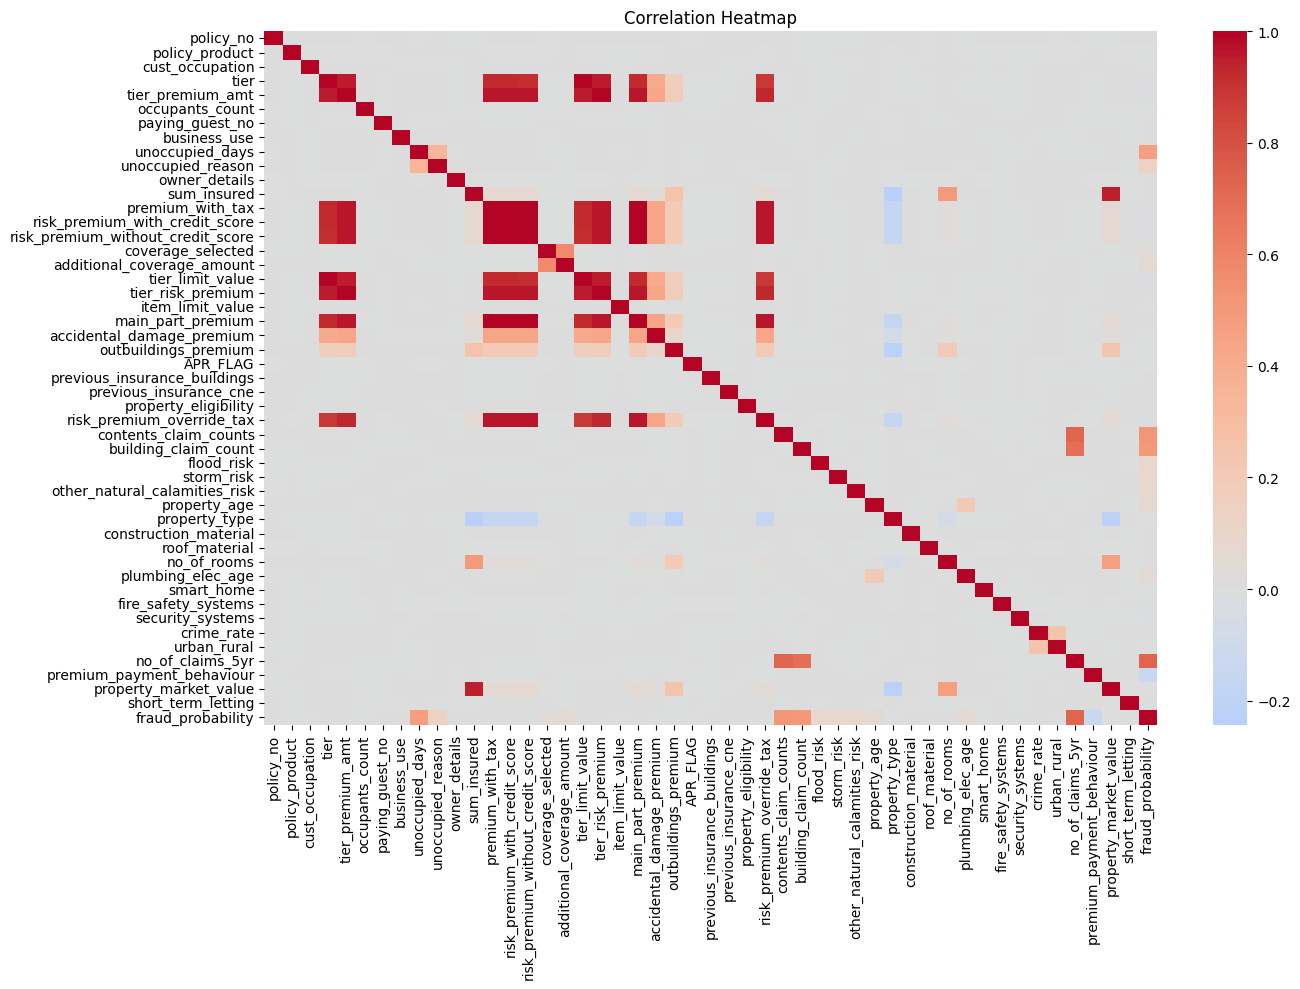


=== Missing Value % by Column ===
policy_no                            0.0
policy_product                       0.0
cust_occupation                      0.0
tier                                 0.0
tier_premium_amt                     0.0
occupants_count                      0.0
paying_guest_no                      0.0
business_use                         0.0
unoccupied_days                      0.0
unoccupied_reason                    0.0
owner_details                        0.0
sum_insured                          0.0
premium_with_tax                     0.0
risk_premium_with_credit_score       0.0
risk_premium_without_credit_score    0.0
coverage_selected                    0.0
additional_coverage_amount           0.0
tier_limit_value                     0.0
tier_risk_premium                    0.0
item_limit_value                     0.0
main_part_premium                    0.0
accidental_damage_premium            0.0
outbuildings_premium                 0.0
APR_FLAG              

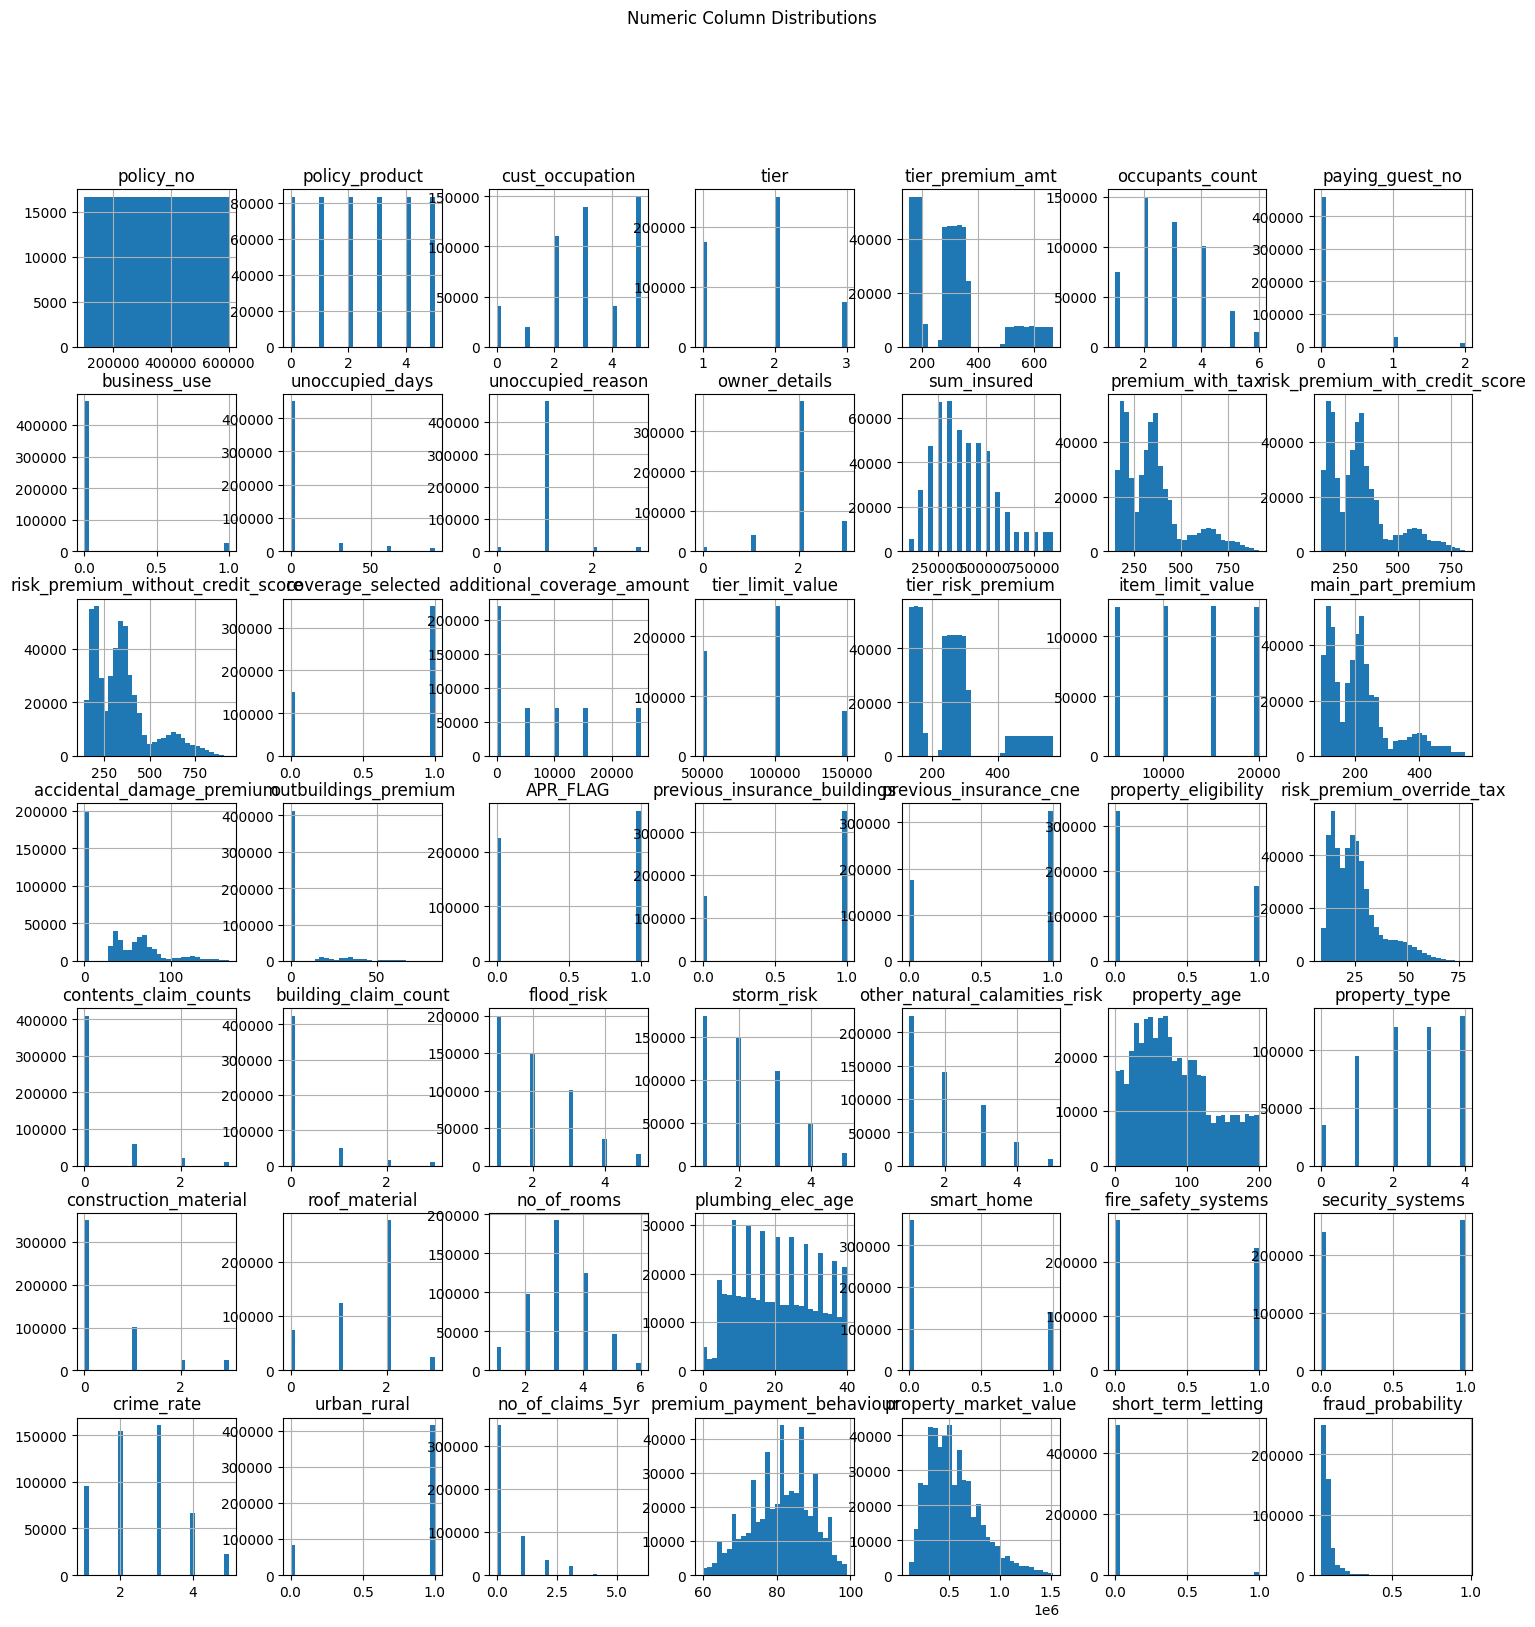


=== Category Counts (Top 20 Each) ===

--- policy_product ---
policy_product
Premium Combined    83602
Buildings           83323
Combined            83298
Standard            83280
Contents            83257
Landlord            83240
Name: count, dtype: int64

--- cust_occupation ---
cust_occupation
white_collar      149787
retired           139603
professional      110083
housewife          40383
skilled_worker     40117
other              20027
Name: count, dtype: int64

--- business_use ---
business_use
N    475061
Y     24939
Name: count, dtype: int64

--- unoccupied_reason ---
unoccupied_reason
relocation      12485
holiday_home    12444
renovation      12248
Name: count, dtype: int64

--- owner_details ---
owner_details
owner          374592
user            74914
legal_lease     40361
financier       10133
Name: count, dtype: int64

--- property_type ---
property_type
Terraced    129922
Semi        120065
Flat        119945
Detached     94851
Bungalow     35217
Name: count, dtype

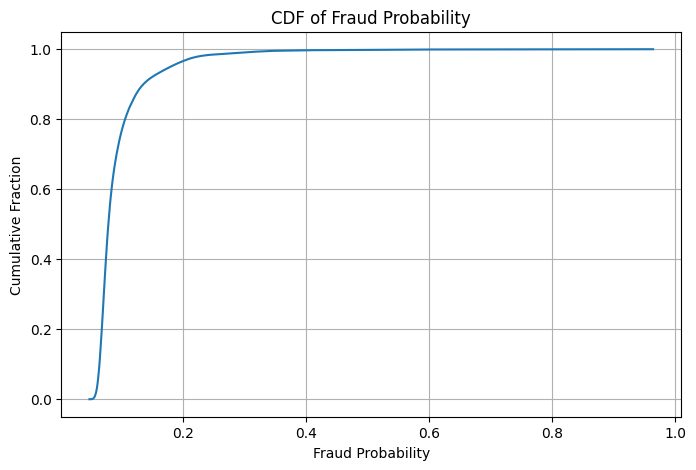


=== Recommended Thresholds ===
19% highest-risk threshold: 0.1066
9% highest-risk threshold: 0.1363
5% highest-risk threshold: 0.1803
2% highest-risk threshold: 0.2274


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. BASIC CLEANING
# ============================================
df_clean = df.copy()

# Convert categorical columns to numeric (label encoding)
from sklearn.preprocessing import LabelEncoder
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

# ============================================
# 2. CORRELATION MATRIX (label + probability)
# ============================================
corr = df_clean.corr()

corr_with_prob = corr["fraud_probability"].sort_values(ascending=False)

print("\n=== Correlation with fraud_probability ===")
print(corr_with_prob.head(20))

# ===== Heatmap =====
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================
# 3. INDUSTRY-STYLE EDA TOOLS
# ============================================

# Missing values
print("\n=== Missing Value % by Column ===")
print(df_clean.isnull().mean().sort_values(ascending=False) * 100)

# Distribution of key numeric fields
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

df_clean[numeric_cols].hist(figsize=(18, 18), bins=30)
plt.suptitle("Numeric Column Distributions")
plt.show()

# High-cardinality categorical levels
print("\n=== Category Counts (Top 20 Each) ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(20))

# ============================================
# 4. FRAUD PROBABILITY CDF (CUMULATIVE CURVE)
# ============================================

fraud_probs = df["fraud_probability"].sort_values().values
cdf = np.arange(1, len(fraud_probs)+1) / len(fraud_probs)

plt.figure(figsize=(8,5))
plt.plot(fraud_probs, cdf)
plt.xlabel("Fraud Probability")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of Fraud Probability")
plt.grid(True)
plt.show()

# ============================================
# 5. NUMERIC THRESHOLD FINDER
# ============================================

# Example: flag top 2%, 5%, 10%, 20% highest risk cases
percentiles = [0.80, 0.90, 0.95, 0.98]

print("\n=== Recommended Thresholds ===")
for p in percentiles:
    threshold = np.quantile(fraud_probs, p)
    print(f"{int((1-p)*100)}% highest-risk threshold: {threshold:.4f}")


In [36]:
# Set UK-standard realistic fraud threshold
uk_threshold = 0.18

df["fraud_label"] = (df["fraud_probability"] >= uk_threshold).astype(int)

print("UK-standard fraud threshold set at:", uk_threshold)
print("Fraud rate in dataset:", df["fraud_label"].mean())

UK-standard fraud threshold set at: 0.18
Fraud rate in dataset: 0.050282


In [ ]:
df.to_csv("data_5L_new.csv", index=False)

## Baseline models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns


# ==================== COST CALCULATION FUNCTIONS ====================

def calculate_costs(sum_insured, y_true, y_pred):
    """
    Calculate instance-dependent costs for fraud detection.
    
    Cost structure:
    - FN (Missing fraud): Lose 90% of sum_insured (fraud payout)
    - FP (False accusation): Fixed £100 administrative + customer relation cost
    - TN (Correct rejection): £0
    - TP (Caught fraud): £0
    """
    costs = np.zeros(len(y_true))
    
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # False Negative (missed fraud)
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # False Positive (false accusation)
            costs[i] = 100
        # True Positive and True Negative have 0 cost
    
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive cost-sensitive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    total_cost = np.sum(costs)
    
    # Breakdown by error type
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    
    fn_cost = np.sum(costs[fn_mask])
    fp_cost = np.sum(costs[fp_mask])
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)
    
    # Traditional metrics
    tn = np.sum((y_true == 0) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    
    results = {
        'total_cost': total_cost,
        'fn_cost': fn_cost,
        'fp_cost': fp_cost,
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp,
        'tn': tn,
        'avg_cost_per_sample': total_cost / len(y_true)
    }
    
    # Calculate rates
    if tp + fn_count > 0:
        results['recall'] = tp / (tp + fn_count)
    else:
        results['recall'] = 0
    
    if tp + fp_count > 0:
        results['precision'] = tp / (tp + fp_count)
    else:
        results['precision'] = 0
    
    return results


# ==================== IDCSPA ALGORITHM ====================

class IDCSPA:
    """Instance-Dependent Cost-Sensitive Passive-Aggressive algorithm."""
    
    def __init__(self, n_features, C=1.0):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.C = C
        self.loss_history = []

    def decision_function(self, X):
        """Compute decision scores."""
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        """Predict labels."""
        scores = self.decision_function(X)
        return (scores >= 0).astype(int)

    def compute_cost_weight(self, sum_insured, y_true):
        """Compute instance-dependent cost weight."""
        FP_cost = 100
        FN_cost = sum_insured * 0.9
        
        if y_true == 1:  # Fraud case
            return FN_cost  # Cost of missing fraud
        else:  # Legitimate case
            return FP_cost  # Cost of false accusation

    def update(self, x, y, sum_insured):
        """Perform PA update with instance-dependent cost."""
        cost_weight = self.compute_cost_weight(sum_insured, y)
        
        # Compute margin
        y_signed = 2 * y - 1  # Convert {0,1} to {-1,1}
        margin = y_signed * (np.dot(self.w, x) + self.b)
        
        # Compute loss (hinge loss weighted by cost)
        loss = cost_weight * max(0, 1 - margin)
        self.loss_history.append(loss)
        
        # PA update if loss > 0
        if loss > 0:
            norm_sq = np.dot(x, x) + 1
            tau = min(self.C, loss / norm_sq)
            
            self.w += tau * y_signed * cost_weight * x
            self.b += tau * y_signed * cost_weight

    def fit(self, X, y, sum_insured, epochs=1):
        """Train the model using online learning."""
        n_samples = len(X)
        
        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            
            for idx in indices:
                self.update(X[idx], y[idx], sum_insured[idx])
            
            if (epoch + 1) % 1 == 0:
                train_pred = self.predict(X)
                eval_results = evaluate_cost_sensitive(y, train_pred, sum_insured)
                avg_loss = np.mean(self.loss_history[-n_samples:])
                print(f"Epoch {epoch+1}/{epochs}: Avg Loss={avg_loss:.2f}, Total Cost=£{eval_results['total_cost']:,.0f}")


# ==================== LOGISTIC BANDIT ALGORITHM ====================

class CostSensitiveLogisticBandit:
    """Cost-Sensitive Logistic Bandit using Thompson Sampling."""
    
    def __init__(self, n_features, alpha=1.0):
        self.n_features = n_features
        self.alpha = alpha
        
        self.mean = np.zeros(n_features + 1)
        self.cov = np.eye(n_features + 1) * alpha
        self.cov_inv = np.linalg.inv(self.cov)
        
        self.rewards_history = []
        self.costs_history = []

    def _add_bias(self, X):
        """Add bias term to features."""
        if len(X.shape) == 1:
            return np.append(X, 1)
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def sample_theta(self):
        """Sample parameters from posterior distribution."""
        return np.random.multivariate_normal(self.mean, self.cov)

    def predict_proba(self, X, theta=None):
        """Predict probability of fraud using logistic function."""
        X_bias = self._add_bias(X)
        if theta is None:
            theta = self.mean
        logits = np.dot(X_bias, theta)
        return 1 / (1 + np.exp(-np.clip(logits, -500, 500)))  # Clip for stability

    def select_action(self, X, sum_insured):
        """Select action based on cost-sensitive policy using Thompson Sampling."""
        theta = self.sample_theta()
        fraud_prob = self.predict_proba(X, theta)
        
        # Calculate expected costs
        FN_cost = sum_insured * 0.9
        expected_cost_approve = fraud_prob * FN_cost  # Treat as non-fraud
        
        FP_cost = 100
        expected_cost_reject = (1 - fraud_prob) * FP_cost  # Treat as fraud
        
        # Choose action with lower expected cost
        if expected_cost_approve < expected_cost_reject:
            return 0  # Predict legitimate (approve)
        else:
            return 1  # Predict fraud (reject)

    def update(self, X, y, sum_insured):
        """Update posterior distribution based on observed outcome."""
        X_bias = self._add_bias(X)
        
        # Compute prediction
        p = self.predict_proba(X, self.mean)
        
        # Compute gradient and Hessian
        grad = X_bias * (y - p)
        H = np.outer(X_bias, X_bias) * p * (1 - p)
        
        # Update precision matrix
        self.cov_inv += H
        self.cov = np.linalg.inv(self.cov_inv)
        
        # Update mean
        self.mean = self.cov @ (self.cov_inv @ self.mean + grad)
        
        # Track performance
        action = self.select_action(X, sum_insured)
        cost = calculate_costs(np.array([sum_insured]), np.array([y]), np.array([action]))[0]
        self.costs_history.append(cost)
        self.rewards_history.append(-cost)

    def fit(self, X, y, sum_insured):
        """Train the bandit online."""
        n_samples = len(X)
        
        for i in range(n_samples):
            self.update(X[i], y[i], sum_insured[i])
            
            if (i + 1) % 1000 == 0:
                recent_cost = np.sum(self.costs_history[-1000:])
                print(f"Processed {i+1}/{n_samples} samples, Recent 1000 samples cost: £{recent_cost:,.0f}")

    def predict(self, X, sum_insured):
        """Predict actions for a batch of samples."""
        predictions = []
        for i in range(len(X)):
            action = self.select_action(X[i], sum_insured[i])
            predictions.append(action)
        return np.array(predictions)


# ==================== COST-SENSITIVE WRAPPER FOR SKLEARN MODELS ====================

class CostSensitiveClassifier:
    """Wrapper to make sklearn classifiers cost-sensitive via threshold adjustment."""
    
    def __init__(self, base_classifier):
        self.classifier = base_classifier
        self.optimal_threshold = 0.5
    
    def fit(self, X, y, sum_insured=None):
        """Fit the base classifier."""
        self.classifier.fit(X, y)
        
        # Find optimal threshold if sum_insured provided
        if sum_insured is not None:
            self._find_optimal_threshold(X, y, sum_insured)
        
        return self
    
    def _find_optimal_threshold(self, X, y, sum_insured):
        """Find threshold that minimizes cost on training data."""
        y_proba = self.classifier.predict_proba(X)[:, 1]
        
        # Try different thresholds
        thresholds = np.linspace(0.05, 0.95, 100)
        best_cost = float('inf')
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            cost = np.sum(calculate_costs(sum_insured, y, y_pred))
            
            if cost < best_cost:
                best_cost = cost
                best_threshold = threshold
        
        self.optimal_threshold = best_threshold
        print(f"Optimal threshold found: {self.optimal_threshold:.3f} (Cost: £{best_cost:,.0f})")
    
    def predict(self, X):
        """Predict using optimal threshold."""
        y_proba = self.classifier.predict_proba(X)[:, 1]
        return (y_proba >= self.optimal_threshold).astype(int)
    
    def predict_proba(self, X):
        """Return probability predictions."""
        return self.classifier.predict_proba(X)


# ==================== MAIN COMPARISON FRAMEWORK ====================

def prepare_data(df):
    """Prepare data for modeling."""
    # Select relevant features for fraud detection
    feature_cols = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]
    
    # One-hot encode categorical variables
    categorical_cols = ['cust_occupation', 'owner_details', 'property_type', 
                       'construction_material', 'roof_material', 'urban_rural', 'policy_product']
    
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Get all feature columns (original + encoded)
    all_features = [col for col in df_encoded.columns if col in feature_cols or 
                   any(cat in col for cat in categorical_cols)]
    
    X = df_encoded[all_features].values
    y = df['fraud_label'].values
    sum_insured = df['sum_insured'].values
    
    return X, y, sum_insured, all_features


def compare_all_models(df):
    """Compare all models with cost-sensitive evaluation."""
    
    print("\n" + "="*80)
    print("PREPARING DATA")
    print("="*80)
    
    # Prepare data
    X, y, sum_insured, feature_names = prepare_data(df)
    
    # Split data
    X_train, X_test, y_train, y_test, sum_train, sum_test = train_test_split(
        X, y, sum_insured, test_size=0.3, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Fraud rate (train): {y_train.mean()*100:.2f}%")
    print(f"Fraud rate (test): {y_test.mean()*100:.2f}%")
    print(f"Number of features: {X_train.shape[1]}")
    
    # Store results
    results = {}
    
    # ==================== 1. LOGISTIC REGRESSION ====================
    print("\n" + "="*80)
    print("1. TRAINING LOGISTIC REGRESSION")
    print("="*80)
    
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr_cost_sensitive = CostSensitiveClassifier(lr)
    lr_cost_sensitive.fit(X_train_scaled, y_train, sum_train)
    
    y_pred_lr = lr_cost_sensitive.predict(X_test_scaled)
    results['Logistic Regression'] = evaluate_cost_sensitive(y_test, y_pred_lr, sum_test)
    results['Logistic Regression']['y_pred'] = y_pred_lr
    
    # ==================== 2. DECISION TREE ====================
    print("\n" + "="*80)
    print("2. TRAINING DECISION TREE")
    print("="*80)
    
    dt = DecisionTreeClassifier(max_depth=10, min_samples_split=50, 
                                min_samples_leaf=20, random_state=42, class_weight='balanced')
    dt_cost_sensitive = CostSensitiveClassifier(dt)
    dt_cost_sensitive.fit(X_train_scaled, y_train, sum_train)
    
    y_pred_dt = dt_cost_sensitive.predict(X_test_scaled)
    results['Decision Tree'] = evaluate_cost_sensitive(y_test, y_pred_dt, sum_test)
    results['Decision Tree']['y_pred'] = y_pred_dt
    
    # ==================== 3. XGBOOST ====================
    print("\n" + "="*80)
    print("3. TRAINING XGBOOST")
    print("="*80)
    
    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_cost_sensitive = CostSensitiveClassifier(xgb)
    xgb_cost_sensitive.fit(X_train_scaled, y_train, sum_train)
    
    y_pred_xgb = xgb_cost_sensitive.predict(X_test_scaled)
    results['XGBoost'] = evaluate_cost_sensitive(y_test, y_pred_xgb, sum_test)
    results['XGBoost']['y_pred'] = y_pred_xgb
    
    # ==================== 4. IDCSPA ====================
    print("\n" + "="*80)
    print("4. TRAINING IDCSPA")
    print("="*80)
    
    idcspa = IDCSPA(n_features=X_train_scaled.shape[1], C=1.0)
    idcspa.fit(X_train_scaled, y_train, sum_train, epochs=3)
    
    y_pred_idcspa = idcspa.predict(X_test_scaled)
    results['IDCSPA'] = evaluate_cost_sensitive(y_test, y_pred_idcspa, sum_test)
    results['IDCSPA']['y_pred'] = y_pred_idcspa
    
    # ==================== 5. LOGISTIC BANDIT ====================
    print("\n" + "="*80)
    print("5. TRAINING LOGISTIC BANDIT")
    print("="*80)
    
    bandit = CostSensitiveLogisticBandit(n_features=X_train_scaled.shape[1], alpha=1.0)
    bandit.fit(X_train_scaled, y_train, sum_train)
    
    y_pred_bandit = bandit.predict(X_test_scaled, sum_test)
    results['Logistic Bandit'] = evaluate_cost_sensitive(y_test, y_pred_bandit, sum_test)
    results['Logistic Bandit']['y_pred'] = y_pred_bandit
    
    # ==================== RESULTS SUMMARY ====================
    print("\n" + "="*80)
    print("FINAL RESULTS COMPARISON")
    print("="*80)
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Total Cost (£)': [results[m]['total_cost'] for m in results.keys()],
        'FN Cost (£)': [results[m]['fn_cost'] for m in results.keys()],
        'FP Cost (£)': [results[m]['fp_cost'] for m in results.keys()],
        'FN Count': [results[m]['fn_count'] for m in results.keys()],
        'FP Count': [results[m]['fp_count'] for m in results.keys()],
        'TP Count': [results[m]['tp'] for m in results.keys()],
        'Recall': [results[m]['recall'] for m in results.keys()],
        'Precision': [results[m]['precision'] for m in results.keys()],
        'Avg Cost/Sample (£)': [results[m]['avg_cost_per_sample'] for m in results.keys()]
    })
    
    comparison_df = comparison_df.sort_values('Total Cost (£)')
    
    print("\n" + comparison_df.to_string(index=False))
    
    # Calculate cost savings
    baseline_cost = comparison_df['Total Cost (£)'].max()
    comparison_df['Cost Savings (£)'] = baseline_cost - comparison_df['Total Cost (£)']
    comparison_df['Cost Savings (%)'] = (comparison_df['Cost Savings (£)'] / baseline_cost * 100)
    
    print("\n" + "="*80)
    print("COST SAVINGS ANALYSIS")
    print("="*80)
    print(comparison_df[['Model', 'Total Cost (£)', 'Cost Savings (£)', 'Cost Savings (%)']].to_string(index=False))
    
    # ==================== VISUALIZATION ====================
    
    # 1. Total Cost Comparison
    plt.figure(figsize=(14, 10))
    
    plt.subplot(2, 2, 1)
    models = comparison_df['Model']
    costs = comparison_df['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' 
              for c in costs]
    plt.barh(models, costs, color=colors)
    plt.xlabel('Total Cost (£)', fontsize=11)
    plt.title('Total Cost Comparison (Lower is Better)', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    for i, v in enumerate(costs):
        plt.text(v, i, f' £{v:,.0f}', va='center', fontsize=9)
    
    # 2. FN vs FP Cost Breakdown
    plt.subplot(2, 2, 2)
    x = np.arange(len(models))
    width = 0.35
    plt.bar(x - width/2, comparison_df['FN Cost (£)'], width, label='FN Cost (Missed Fraud)', color='#e74c3c')
    plt.bar(x + width/2, comparison_df['FP Cost (£)'], width, label='FP Cost (False Accusation)', color='#f39c12')
    plt.xlabel('Model', fontsize=11)
    plt.ylabel('Cost (£)', fontsize=11)
    plt.title('Cost Breakdown by Error Type', fontsize=12, fontweight='bold')
    plt.xticks(x, models, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    
    # 3. Precision-Recall Trade-off
    plt.subplot(2, 2, 3)
    plt.scatter(comparison_df['Recall'], comparison_df['Precision'], 
               s=200, c=costs, cmap='RdYlGn_r', edgecolors='black', linewidth=2)
    for i, model in enumerate(models):
        plt.annotate(model, (comparison_df['Recall'].iloc[i], comparison_df['Precision'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    plt.xlabel('Recall (Fraud Detection Rate)', fontsize=11)
    plt.ylabel('Precision', fontsize=11)
    plt.title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
    plt.colorbar(label='Total Cost (£)')
    plt.grid(alpha=0.3)
    
    # 4. Error Count Comparison
    plt.subplot(2, 2, 4)
    x = np.arange(len(models))
    width = 0.35
    plt.bar(x - width/2, comparison_df['FN Count'], width, label='False Negatives', color='#e74c3c')
    plt.bar(x + width/2, comparison_df['FP Count'], width, label='False Positives', color='#f39c12')
    plt.xlabel('Model', fontsize=11)
    plt.ylabel('Count', fontsize=11)
    plt.title('Error Count Comparison', fontsize=12, fontweight='bold')
    plt.xticks(x, models, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    
    plt.suptitle('Cost-Sensitive Fraud Detection Model Comparison', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return results, comparison_df


PREPARING DATA
Training samples: 350000
Test samples: 150000
Fraud rate (train): 5.03%
Fraud rate (test): 5.03%
Number of features: 59

1. TRAINING LOGISTIC REGRESSION
Optimal threshold found: 0.186 (Cost: £974,900)

2. TRAINING DECISION TREE
Optimal threshold found: 0.050 (Cost: £646,800)

3. TRAINING XGBOOST
Optimal threshold found: 0.386 (Cost: £449,400)

4. TRAINING IDCSPA
Epoch 1/3: Avg Loss=190585366.42, Total Cost=£8,901,700
Epoch 2/3: Avg Loss=100001711.58, Total Cost=£15,690,300
Epoch 3/3: Avg Loss=92473404.48, Total Cost=£8,499,800

5. TRAINING LOGISTIC BANDIT
Processed 1000/350000 samples, Recent 1000 samples cost: £94,300
Processed 2000/350000 samples, Recent 1000 samples cost: £94,600
Processed 3000/350000 samples, Recent 1000 samples cost: £96,300
Processed 4000/350000 samples, Recent 1000 samples cost: £94,900
Processed 5000/350000 samples, Recent 1000 samples cost: £94,500
Processed 6000/350000 samples, Recent 1000 samples cost: £95,900
Processed 7000/350000 samples, R

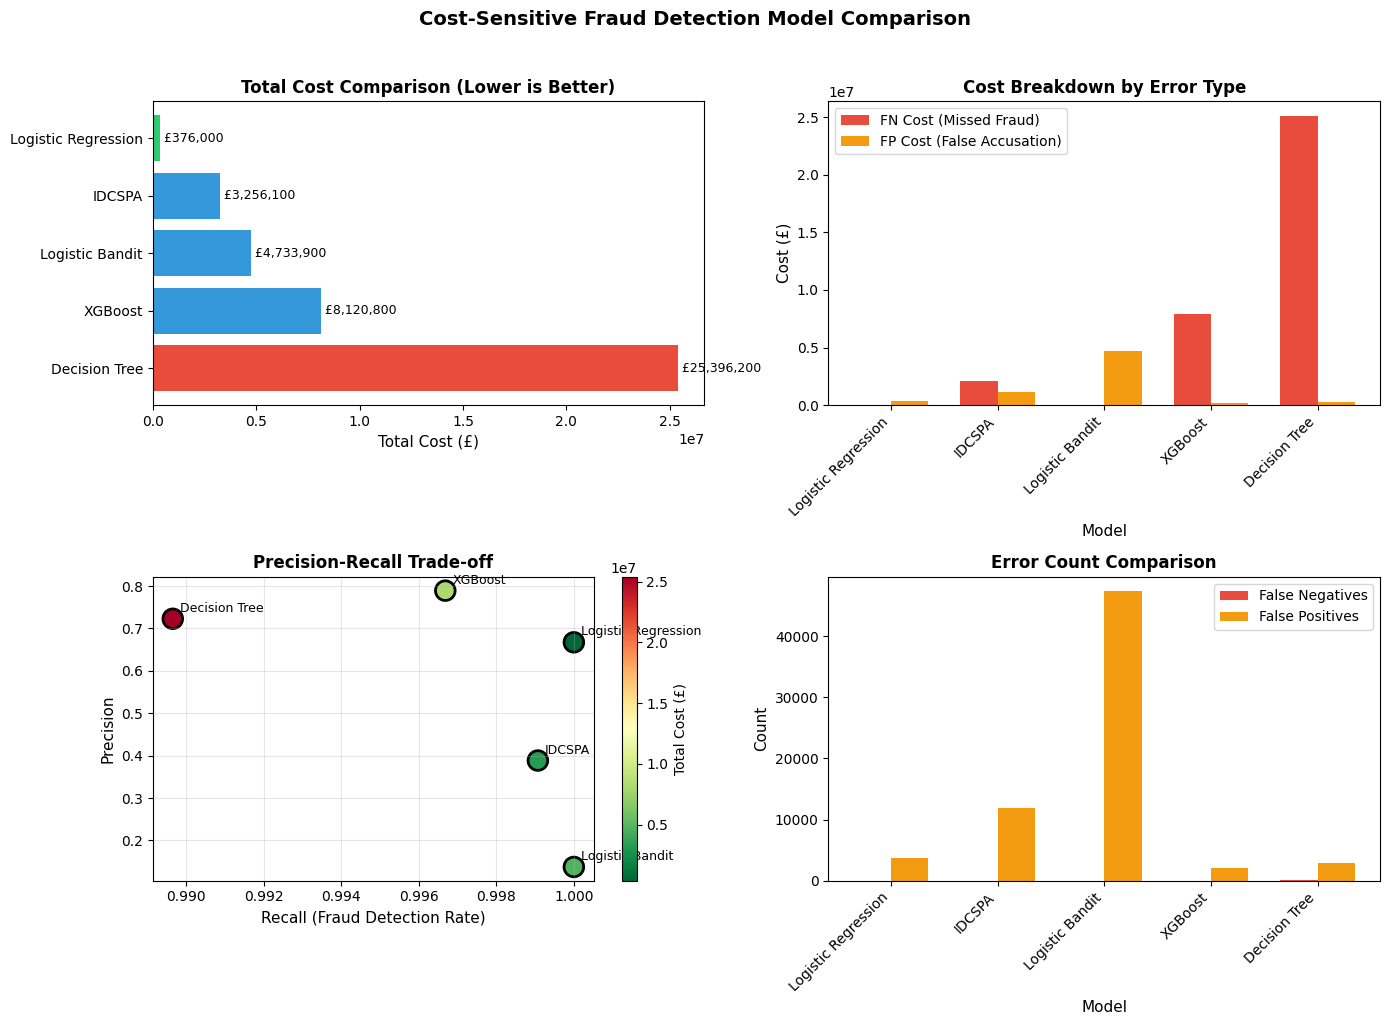


ANALYSIS COMPLETE!

Key Insights:
1. Best performing model: Logistic Regression
2. Lowest total cost: £376,000
3. Cost savings vs worst model: £25,020,200 (98.5%)


In [41]:
# Run comparison
results, comparison_df = compare_all_models(df)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nKey Insights:")
print(f"1. Best performing model: {comparison_df.iloc[0]['Model']}")
print(f"2. Lowest total cost: £{comparison_df.iloc[0]['Total Cost (£)']:,.0f}")
print(f"3. Cost savings vs worst model: £{comparison_df.iloc[0]['Cost Savings (£)']:,.0f} ({comparison_df.iloc[0]['Cost Savings (%)']:.1f}%)")

## Rule-based + active learning old

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ==================== RULE-BASED FRAUD DETECTION ====================

class UKFraudRuleEngine:
    """Industry-standard rule-based fraud detection for UK home insurance."""
    
    def apply_rules(self, df):
        """Apply UK fraud detection rules to dataset."""
        
        rules_df = pd.DataFrame()
        
        # Calculate derived features
        rules_df['claim_ratio'] = df['sum_insured'] / (df['premium_with_tax'] + 1)
        rules_df['coverage_ratio'] = df['sum_insured'] / (df['property_market_value'] + 1)
        
        # RULE 1: High claim ratio + early claim pattern
        rules_df['rule1'] = (
            (rules_df['claim_ratio'] > 1500) &
            (df['previous_insurance_buildings'] == 0) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 2: Accidental damage + early claim + unoccupied
        rules_df['rule2'] = (
            (df['accidental_damage_premium'] > 0) &
            (df['unoccupied_days'] >= 30) &
            (df['previous_insurance_buildings'] == 0) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 3: High claim frequency
        rules_df['rule3'] = (df['no_of_claims_5yr'] >= 3).astype(int)
        
        # RULE 4: Unoccupied + accidental + business use
        rules_df['rule4'] = (
            (df['unoccupied_days'] >= 30) &
            (df['accidental_damage_premium'] > 0) &
            (df['business_use'] == 'Y') &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 5: Coverage inflation
        rules_df['rule5'] = (
            (rules_df['coverage_ratio'] > 0.8) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 6: Late additional coverage
        rules_df['rule6'] = (
            (df['additional_coverage_amount'] >= 15000) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 7: Payment issues + high claims
        rules_df['rule7'] = (
            (df['premium_payment_behaviour'] < 70) &
            (df['no_of_claims_5yr'] >= 2)
        ).astype(int)
        
        # RULE 8: Short-term letting + high claims
        rules_df['rule8'] = (
            (df['short_term_letting'] == 1) &
            (df['no_of_claims_5yr'] >= 2)
        ).astype(int)
        
        # RULE 9: Exaggerated loss pattern
        rules_df['rule9'] = (
            (df['risk_premium_without_credit_score'] / (df['risk_premium_with_credit_score'] + 1) > 1.2) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # RULE 10: Natural disaster opportunism
        rules_df['rule10'] = (
            ((df['flood_risk'] >= 4) | (df['storm_risk'] >= 4)) &
            (df['unoccupied_days'] >= 30) &
            (df['no_of_claims_5yr'] > 0)
        ).astype(int)
        
        # Aggregate: flag as fraud if ANY rule triggers
        rules_df['fraud_flag'] = (rules_df[[f'rule{i}' for i in range(1, 11)]].sum(axis=1) > 0).astype(int)
        rules_df['rules_triggered_count'] = rules_df[[f'rule{i}' for i in range(1, 11)]].sum(axis=1)
        
        return rules_df


# ==================== IMPROVED ACTIVE LEARNING ====================

class ActiveLearningFraudDetector:
    """
    FIXED Active Learning with:
    - Larger initial training set (30% instead of 10%)
    - Better base model (Random Forest instead of Logistic Regression)
    - Cost-sensitive threshold optimization
    - Aggressive querying strategy
    """
    
    def __init__(self, base_model=None, rule_engine=None):
        if base_model is None:
            # Use Random Forest for better non-linear pattern detection
            base_model = RandomForestClassifier(
                n_estimators=100, 
                max_depth=10,
                min_samples_split=20,
                class_weight='balanced',
                random_state=42
            )
        self.base_model = base_model
        self.rule_engine = rule_engine if rule_engine else UKFraudRuleEngine()
        self.labeled_indices = []
        self.unlabeled_indices = []
        self.optimal_threshold = 0.5
        
    def initialize_with_rules(self, X, df, y_true, initial_budget=0.30):
        """
        FIXED: Initialize with 30% of data using smart sampling strategy.
        """
        # Apply rules to identify high-confidence samples
        rules_result = self.rule_engine.apply_rules(df)
        
        # Strategy 1: Get all rule-flagged frauds (high confidence)
        rule_fraud_indices = np.where(rules_result['fraud_flag'] == 1)[0]
        
        # Strategy 2: Sample legitimate cases (no claims, no rules triggered)
        safe_legitimate = (rules_result['rules_triggered_count'] == 0) & (df['no_of_claims_5yr'] == 0)
        legitimate_indices = np.where(safe_legitimate)[0]
        
        # Strategy 3: Add diverse borderline cases (1 rule triggered)
        borderline_indices = np.where(rules_result['rules_triggered_count'] == 1)[0]
        
        # Combine: all frauds + balanced legitimate + some borderline
        n_initial = int(len(X) * initial_budget)
        
        # Take all rule-flagged frauds
        initial_indices = list(rule_fraud_indices)
        
        # Add legitimate samples (match fraud count for balance)
        n_legitimate_needed = min(len(rule_fraud_indices), len(legitimate_indices))
        if n_legitimate_needed > 0:
            legitimate_sample = np.random.choice(legitimate_indices, n_legitimate_needed, replace=False)
            initial_indices.extend(legitimate_sample)
        
        # Fill remaining budget with borderline cases
        remaining = n_initial - len(initial_indices)
        if remaining > 0 and len(borderline_indices) > 0:
            n_borderline = min(remaining, len(borderline_indices))
            borderline_sample = np.random.choice(borderline_indices, n_borderline, replace=False)
            initial_indices.extend(borderline_sample)
        
        # If still under budget, add random samples
        if len(initial_indices) < n_initial:
            all_indices = set(range(len(X)))
            available = list(all_indices - set(initial_indices))
            remaining = n_initial - len(initial_indices)
            if len(available) > 0:
                additional = np.random.choice(available, min(remaining, len(available)), replace=False)
                initial_indices.extend(additional)
        
        self.labeled_indices = list(set(initial_indices))
        self.unlabeled_indices = list(set(range(len(X))) - set(self.labeled_indices))
        
        # Get TRUE labels (not rule labels)
        y_initial = y_true[self.labeled_indices]
        
        return y_initial
    
    def find_optimal_threshold(self, X, y, sum_insured):
        """Find cost-minimizing threshold on validation set."""
        
        proba = self.base_model.predict_proba(X)[:, 1]
        
        # Try thresholds from 0.1 to 0.9
        thresholds = np.linspace(0.1, 0.9, 50)
        best_cost = float('inf')
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (proba >= threshold).astype(int)
            cost = np.sum(calculate_costs(sum_insured, y, y_pred))
            
            if cost < best_cost:
                best_cost = cost
                best_threshold = threshold
        
        self.optimal_threshold = best_threshold
        return best_threshold, best_cost
    
    def uncertainty_sampling(self, X_unlabeled, sum_insured_unlabeled, n_queries=100):
        """
        FIXED: More aggressive uncertainty sampling.
        Focus on high-value cases with probability 0.3-0.7 (not just near 0.5).
        """
        proba = self.base_model.predict_proba(X_unlabeled)[:, 1]
        
        # Broaden uncertainty range: accept 0.3 to 0.7
        uncertainty = 1 - np.abs(proba - 0.5) * 1.5  # Less strict than before
        uncertainty = np.clip(uncertainty, 0, 1)
        
        # High weight on sum_insured
        cost_weight = (sum_insured_unlabeled / sum_insured_unlabeled.mean()) ** 0.5
        
        # Combined score
        query_score = uncertainty * cost_weight
        
        # Add randomness to avoid getting stuck
        query_score += np.random.random(len(query_score)) * 0.1
        
        # Select top n_queries
        query_indices = np.argsort(query_score)[-n_queries:]
        
        return query_indices
    
    def fit(self, X, y_true, df, sum_insured, query_budget=0.40, batch_size=50, verbose=True):
        """
        FIXED: Train with 40% total budget (30% initial + 10% queries).
        """
        
        if verbose:
            print("="*80)
            print("ACTIVE LEARNING: Improved Strategy")
            print("="*80)
        
        # Step 1: Larger initial training set (30%)
        y_initial = self.initialize_with_rules(X, df, y_true, initial_budget=0.30)
        
        if verbose:
            print(f"Initial labeled samples: {len(self.labeled_indices)} (30% of training data)")
            print(f"Initial fraud rate: {y_initial.mean()*100:.2f}%")
        
        # Step 2: Train initial model
        X_labeled = X[self.labeled_indices]
        y_labeled = y_initial
        
        self.base_model.fit(X_labeled, y_labeled)
        
        # Find optimal threshold on initial labeled data
        sum_labeled = sum_insured[self.labeled_indices]
        threshold, cost = self.find_optimal_threshold(X_labeled, y_labeled, sum_labeled)
        if verbose:
            print(f"Optimal threshold: {threshold:.3f} (Initial cost: £{cost:,.0f})")
        
        # Step 3: Active learning loop (additional 10%)
        additional_budget = query_budget - 0.30
        max_queries = int(len(X) * additional_budget)
        n_iterations = max(1, max_queries // batch_size)
        
        for iteration in range(n_iterations):
            if len(self.unlabeled_indices) == 0:
                break
            
            # Get unlabeled data
            X_unlabeled = X[self.unlabeled_indices]
            sum_insured_unlabeled = sum_insured[self.unlabeled_indices]
            
            # Query uncertain high-value samples
            n_to_query = min(batch_size, len(self.unlabeled_indices))
            query_indices_local = self.uncertainty_sampling(X_unlabeled, sum_insured_unlabeled, n_queries=n_to_query)
            
            # Map to global indices
            query_indices_global = [self.unlabeled_indices[i] for i in query_indices_local]
            
            # Get true labels
            y_queried = y_true[query_indices_global]
            
            # Update sets
            self.labeled_indices.extend(query_indices_global)
            self.unlabeled_indices = [idx for idx in self.unlabeled_indices if idx not in query_indices_global]
            
            # Retrain
            X_labeled = X[self.labeled_indices]
            y_labeled = y_true[self.labeled_indices]
            
            self.base_model.fit(X_labeled, y_labeled)
            
            # Update threshold
            sum_labeled = sum_insured[self.labeled_indices]
            self.find_optimal_threshold(X_labeled, y_labeled, sum_labeled)
            
            if verbose and (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration+1}/{n_iterations}: Labeled={len(self.labeled_indices)}, "
                      f"Queried fraud rate={y_queried.mean()*100:.2f}%, Threshold={self.optimal_threshold:.3f}")
        
        if verbose:
            print(f"\nActive Learning complete. Total labeled: {len(self.labeled_indices)} ({len(self.labeled_indices)/len(X)*100:.1f}%)")
            print(f"Final optimal threshold: {self.optimal_threshold:.3f}")
    
    def predict(self, X):
        """Predict using optimal threshold."""
        proba = self.base_model.predict_proba(X)[:, 1]
        return (proba >= self.optimal_threshold).astype(int)
    
    def predict_proba(self, X):
        """Predict fraud probabilities."""
        return self.base_model.predict_proba(X)


# ==================== EVALUATION & COMPARISON ====================

def compare_with_active_learning(df):
    """Compare Active Learning against all previous models."""
        
    print("\n" + "="*80)
    print("ACTIVE LEARNING vs BASELINES")
    print("="*80)
    
    # Prepare data
    X, y, sum_insured, feature_names = prepare_data(df)
    
    # Split data
    X_train, X_test, y_train, y_test, sum_train, sum_test, df_train, df_test = train_test_split(
        X, y, sum_insured, df, test_size=0.3, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Test fraud rate: {y_test.mean()*100:.2f}%")
    
    # ==================== 1. RULE-BASED ====================
    print("\n" + "="*80)
    print("1. RULE-BASED BASELINE")
    print("="*80)
    
    rule_engine = UKFraudRuleEngine()
    rules_test = rule_engine.apply_rules(df_test.reset_index(drop=True))
    y_pred_rules = rules_test['fraud_flag'].values
    
    results_rules = evaluate_cost_sensitive(y_test, y_pred_rules, sum_test)
    print(f"Total Cost: £{results_rules['total_cost']:,.0f}")
    print(f"Recall: {results_rules['recall']*100:.2f}%")
    print(f"Precision: {results_rules['precision']*100:.2f}%")
    
    # ==================== 2. ACTIVE LEARNING ====================
    print("\n" + "="*80)
    print("2. ACTIVE LEARNING (IMPROVED)")
    print("="*80)
    
    al_detector = ActiveLearningFraudDetector()
    al_detector.fit(X_train_scaled, y_train, df_train.reset_index(drop=True), 
                   sum_train, query_budget=0.40, batch_size=50, verbose=True)
    
    y_pred_al = al_detector.predict(X_test_scaled)
    results_al = evaluate_cost_sensitive(y_test, y_pred_al, sum_test)
    
    print(f"\nTest Results:")
    print(f"Total Cost: £{results_al['total_cost']:,.0f}")
    print(f"Recall: {results_al['recall']*100:.2f}%")
    print(f"Precision: {results_al['precision']*100:.2f}%")
    
    # ==================== 3. BASELINE ML (Full Supervision) ====================
    print("\n" + "="*80)
    print("3. SUPERVISED BASELINE (100% Labels)")
    print("="*80)
    
    from sklearn.ensemble import RandomForestClassifier
    
    rf_full = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
    rf_full_cs = CostSensitiveClassifier(rf_full)
    rf_full_cs.fit(X_train_scaled, y_train, sum_train)
    
    y_pred_full = rf_full_cs.predict(X_test_scaled)
    results_full = evaluate_cost_sensitive(y_test, y_pred_full, sum_test)
    
    print(f"Total Cost: £{results_full['total_cost']:,.0f}")
    print(f"Recall: {results_full['recall']*100:.2f}%")
    print(f"Precision: {results_full['precision']*100:.2f}%")
    
    # ==================== COMPARISON ====================
    print("\n" + "="*80)
    print("FINAL COMPARISON")
    print("="*80)
    
    comparison = pd.DataFrame({
        'Model': ['Rule-Based', 'Active Learning (40% labels)', 'Supervised RF (100% labels)'],
        'Total Cost (£)': [results_rules['total_cost'], results_al['total_cost'], results_full['total_cost']],
        'FN Cost (£)': [results_rules['fn_cost'], results_al['fn_cost'], results_full['fn_cost']],
        'FP Cost (£)': [results_rules['fp_cost'], results_al['fp_cost'], results_full['fp_cost']],
        'Recall (%)': [results_rules['recall']*100, results_al['recall']*100, results_full['recall']*100],
        'Precision (%)': [results_rules['precision']*100, results_al['precision']*100, results_full['precision']*100],
        'Labels Used (%)': [0, 40, 100]
    })
    
    comparison = comparison.sort_values('Total Cost (£)')
    print("\n" + comparison.to_string(index=False))
    
    # Calculate improvements
    al_vs_rules = (results_rules['total_cost'] - results_al['total_cost']) / results_rules['total_cost'] * 100
    al_vs_full = (results_full['total_cost'] - results_al['total_cost']) / results_full['total_cost'] * 100
    
    print(f"\n{'='*80}")
    print("KEY INSIGHTS")
    print(f"{'='*80}")
    print(f"Active Learning vs Rule-Based: {al_vs_rules:+.1f}% cost change")
    print(f"Active Learning vs Full Supervision: {al_vs_full:+.1f}% cost change")
    print(f"Active Learning uses only 40% of labels vs 100% for supervised")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Cost comparison
    ax1 = axes[0, 0]
    models = comparison['Model']
    costs = comparison['Total Cost (£)']
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    ax1.barh(models, costs, color=colors)
    ax1.set_xlabel('Total Cost (£)', fontsize=11)
    ax1.set_title('Total Cost Comparison', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    for i, v in enumerate(costs):
        ax1.text(v, i, f' £{v:,.0f}', va='center', fontsize=9)
    
    # 2. Recall vs Precision
    ax2 = axes[0, 1]
    colors_scatter = ['red', 'blue', 'green']
    ax2.scatter(comparison['Recall (%)'], comparison['Precision (%)'], 
               s=300, c=colors_scatter, edgecolors='black', linewidth=2, alpha=0.7)
    for i, model in enumerate(models):
        ax2.annotate(model, (comparison['Recall (%)'].iloc[i], comparison['Precision (%)'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax2.set_xlabel('Recall (%)', fontsize=11)
    ax2.set_ylabel('Precision (%)', fontsize=11)
    ax2.set_title('Recall vs Precision Trade-off', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    # 3. Label efficiency
    ax3 = axes[1, 0]
    ax3.scatter(comparison['Labels Used (%)'], comparison['Total Cost (£)'], 
               s=400, c=colors_scatter, edgecolors='black', linewidth=2, alpha=0.7)
    for i, model in enumerate(models):
        ax3.annotate(model, (comparison['Labels Used (%)'].iloc[i], comparison['Total Cost (£)'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax3.set_xlabel('Labels Used (%)', fontsize=11)
    ax3.set_ylabel('Total Cost (£)', fontsize=11)
    ax3.set_title('Label Efficiency', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # 4. Cost breakdown
    ax4 = axes[1, 1]
    x = np.arange(len(models))
    width = 0.35
    ax4.bar(x - width/2, comparison['FN Cost (£)'], width, label='FN Cost (Missed Fraud)', color='#e74c3c')
    ax4.bar(x + width/2, comparison['FP Cost (£)'], width, label='FP Cost (False Alarm)', color='#f39c12')
    ax4.set_xlabel('Model', fontsize=11)
    ax4.set_ylabel('Cost (£)', fontsize=11)
    ax4.set_title('Cost Breakdown', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(['Rules', 'AL', 'Supervised'], rotation=15)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    return results_rules, results_al, results_full, comparison

Dataset: 10000 records, 230 frauds (2.30%)

ACTIVE LEARNING vs BASELINES
Training samples: 7000
Test samples: 3000
Test fraud rate: 2.30%

1. RULE-BASED BASELINE
Total Cost: £15,266,600
Recall: 30.43%
Precision: 3.58%

2. ACTIVE LEARNING (IMPROVED)
ACTIVE LEARNING: Improved Strategy
Initial labeled samples: 2574 (30% of training data)
Initial fraud rate: 3.15%
Optimal threshold: 0.394 (Initial cost: £900)
Iteration 2/14: Labeled=2674, Queried fraud rate=0.00%, Threshold=0.410
Iteration 4/14: Labeled=2774, Queried fraud rate=0.00%, Threshold=0.410
Iteration 6/14: Labeled=2874, Queried fraud rate=2.00%, Threshold=0.410
Iteration 8/14: Labeled=2974, Queried fraud rate=0.00%, Threshold=0.410
Iteration 10/14: Labeled=3074, Queried fraud rate=0.00%, Threshold=0.427
Iteration 12/14: Labeled=3174, Queried fraud rate=2.00%, Threshold=0.410
Iteration 14/14: Labeled=3274, Queried fraud rate=4.00%, Threshold=0.410

Active Learning complete. Total labeled: 3274 (46.8%)
Final optimal threshold: 0.41

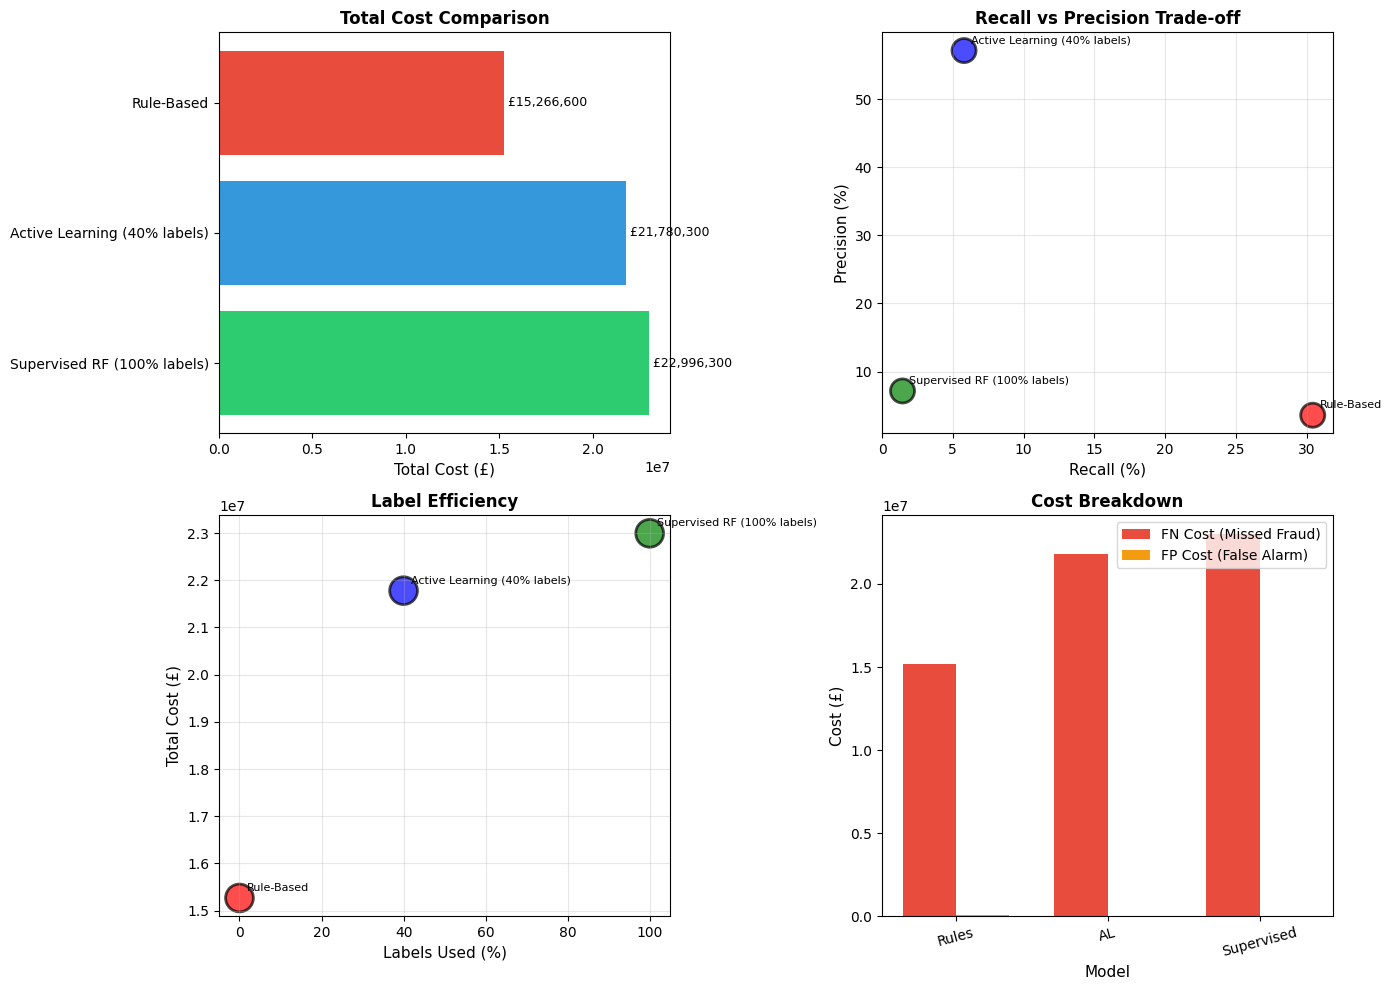


EVALUATION COMPLETE


In [32]:
print(f"Dataset: {len(df)} records, {df['fraud_label'].sum()} frauds ({df['fraud_label'].mean()*100:.2f}%)")

# Run comparison
results_rules, results_al, results_full, comparison = compare_with_active_learning(df)

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)